# 🔢 MNIST Digit Recognition

## SECTION 1 - Environment Setup and Imports

In [1]:
# ── Standard Library ────────────────────────────────────────────────────────
import os, struct, gzip, time, warnings, pickle, copy
from pathlib import Path
warnings.filterwarnings('ignore')

# ── Numerical & Data ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

# ── Scikit-Learn ─────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelBinarizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, ConfusionMatrixDisplay
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

# ── TensorFlow / Keras ───────────────────────────────────────────────────────
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers, models, callbacks, regularizers
    from tensorflow.keras.utils import to_categorical
    TF_AVAILABLE = True
    print(f"TensorFlow {tf.__version__} loaded")
except ImportError:
    TF_AVAILABLE = False
    print("TensorFlow not found Keras cells will be skipped")

# ── PyTorch ──────────────────────────────────────────────────────────────────
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_AVAILABLE = True
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"PyTorch {torch.__version__} loaded device: {DEVICE}")
except ImportError:
    TORCH_AVAILABLE = False
    print("PyTorch not found — PyTorch cells will be skipped")

# ── Global Style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'axes.labelweight': 'bold',
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'font.family': 'DejaVu Sans',
})
sns.set_theme(style='whitegrid', palette='tab10')

# ── Random Seed (Reproducibility) ────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

print("\nAll imports done!")

TensorFlow 2.20.0 loaded
PyTorch 2.8.0+cu126 loaded device: cuda

All imports done!


## SECTION 2 - Loading MNIST (Raw IDX Files)

In [2]:
from pathlib import Path
import numpy as np
import struct
import gzip

# ── Dataset path ────────────────────────────────────────────────────────────
DATA_DIR = Path(r'F:\Umar Nutech Work\Session 4\Dataset')

def read_idx_images(filepath):
    """Parse an IDX3-ubyte image file."""
    filepath = str(filepath)
    open_fn = gzip.open if filepath.endswith('.gz') else open

    with open_fn(filepath, 'rb') as f:
        magic = struct.unpack('>I', f.read(4))[0]
        assert magic == 2051, f"Bad magic number {magic}"

        num_images = struct.unpack('>I', f.read(4))[0]
        rows = struct.unpack('>I', f.read(4))[0]
        cols = struct.unpack('>I', f.read(4))[0]

        data = np.frombuffer(f.read(), dtype=np.uint8)

    return data.reshape(num_images, rows, cols)


def read_idx_labels(filepath):
    """Parse an IDX1-ubyte label file."""
    filepath = str(filepath)
    open_fn = gzip.open if filepath.endswith('.gz') else open

    with open_fn(filepath, 'rb') as f:
        magic = struct.unpack('>I', f.read(4))[0]
        assert magic == 2049, f"Bad magic number {magic}"

        num_labels = struct.unpack('>I', f.read(4))[0]
        data = np.frombuffer(f.read(), dtype=np.uint8)

    return data


# ── Better file finder ──────────────────────────────────────────────────────
def find_file(data_dir, filename):
    # Search recursively for the actual file
    matches = list(data_dir.rglob(filename))

    if not matches:
        raise FileNotFoundError(f"{filename} not found in {data_dir}")

    # Return first real file only
    for m in matches:
        if m.is_file():
            return m

    raise FileNotFoundError(f"No valid file found for {filename}")


# ── Locate dataset files ────────────────────────────────────────────────────
train_images_path = find_file(DATA_DIR, 'train-images-idx3-ubyte')
train_labels_path = find_file(DATA_DIR, 'train-labels-idx1-ubyte')

test_images_path  = find_file(DATA_DIR, 't10k-images-idx3-ubyte')
test_labels_path  = find_file(DATA_DIR, 't10k-labels-idx1-ubyte')


print("Train image file :", train_images_path)
print("Train label file :", train_labels_path)

# ── Load dataset ────────────────────────────────────────────────────────────
X_train_raw = read_idx_images(train_images_path)
y_train     = read_idx_labels(train_labels_path)

X_test_raw  = read_idx_images(test_images_path)
y_test      = read_idx_labels(test_labels_path)

# ── Verify ──────────────────────────────────────────────────────────────────
print("Training images :", X_train_raw.shape, "dtype:", X_train_raw.dtype)
print("Training labels :", y_train.shape, "unique:", np.unique(y_train))

print("Test images     :", X_test_raw.shape)
print("Test labels     :", y_test.shape)

print("Pixel range     : [{}, {}]".format(
    X_train_raw.min(),
    X_train_raw.max()
))

print("\nDataset loaded successfully!")

Train image file : F:\Umar Nutech Work\Session 4\Dataset\train-images-idx3-ubyte\train-images-idx3-ubyte
Train label file : F:\Umar Nutech Work\Session 4\Dataset\train-labels-idx1-ubyte\train-labels-idx1-ubyte
Training images : (60000, 28, 28) dtype: uint8
Training labels : (60000,) unique: [0 1 2 3 4 5 6 7 8 9]
Test images     : (10000, 28, 28)
Test labels     : (10000,)
Pixel range     : [0, 255]

Dataset loaded successfully!


## SECTION 3 - Exploratory Data Analysis (EDA)

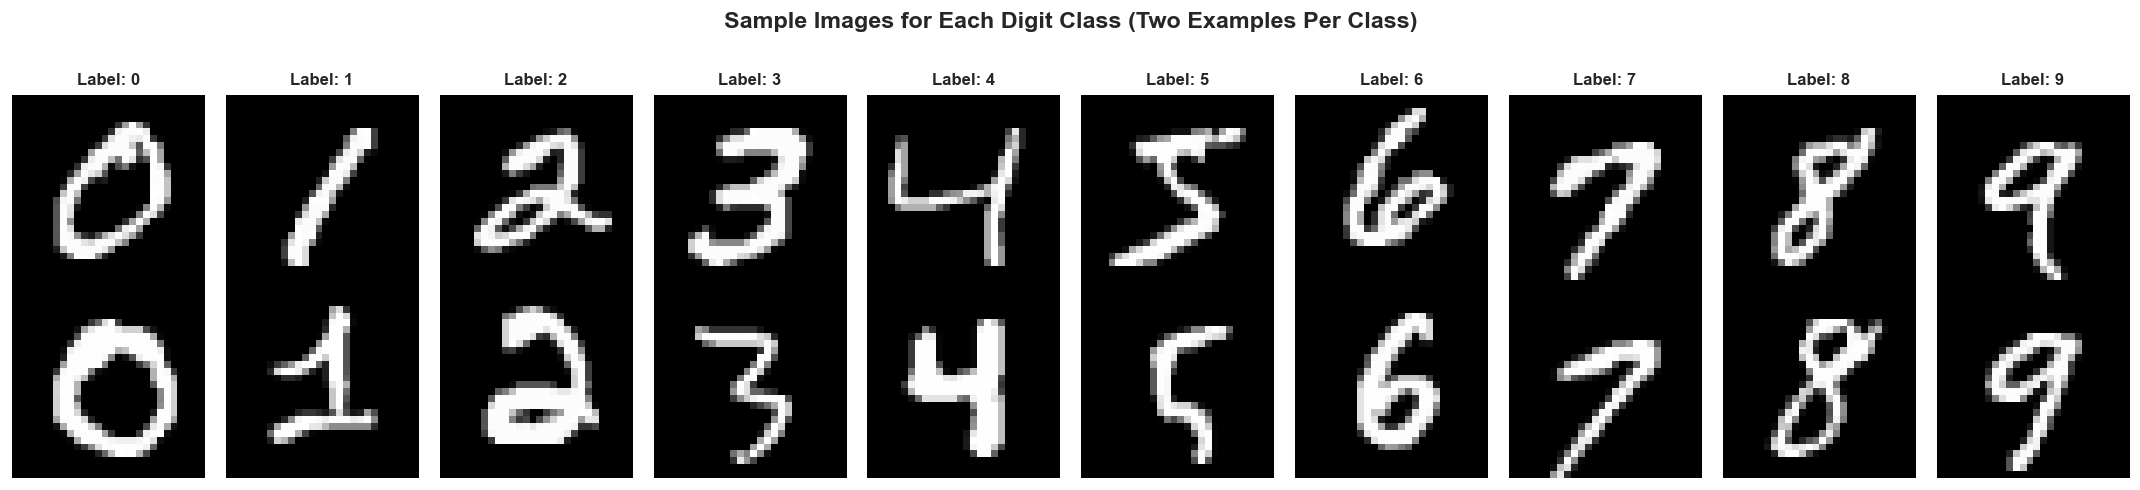

In [3]:
# ── 3.1  Show sample images for each digit ──────────────────────────────────
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    axes[0, digit].imshow(X_train_raw[idx], cmap='gray')
    axes[0, digit].set_title(f'Label: {digit}', fontsize=10, fontweight='bold')
    axes[0, digit].axis('off')

    # Show a second random example
    idx2 = np.where(y_train == digit)[0][5]
    axes[1, digit].imshow(X_train_raw[idx2], cmap='gray')
    axes[1, digit].axis('off')

plt.suptitle('Sample Images for Each Digit Class (Two Examples Per Class)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

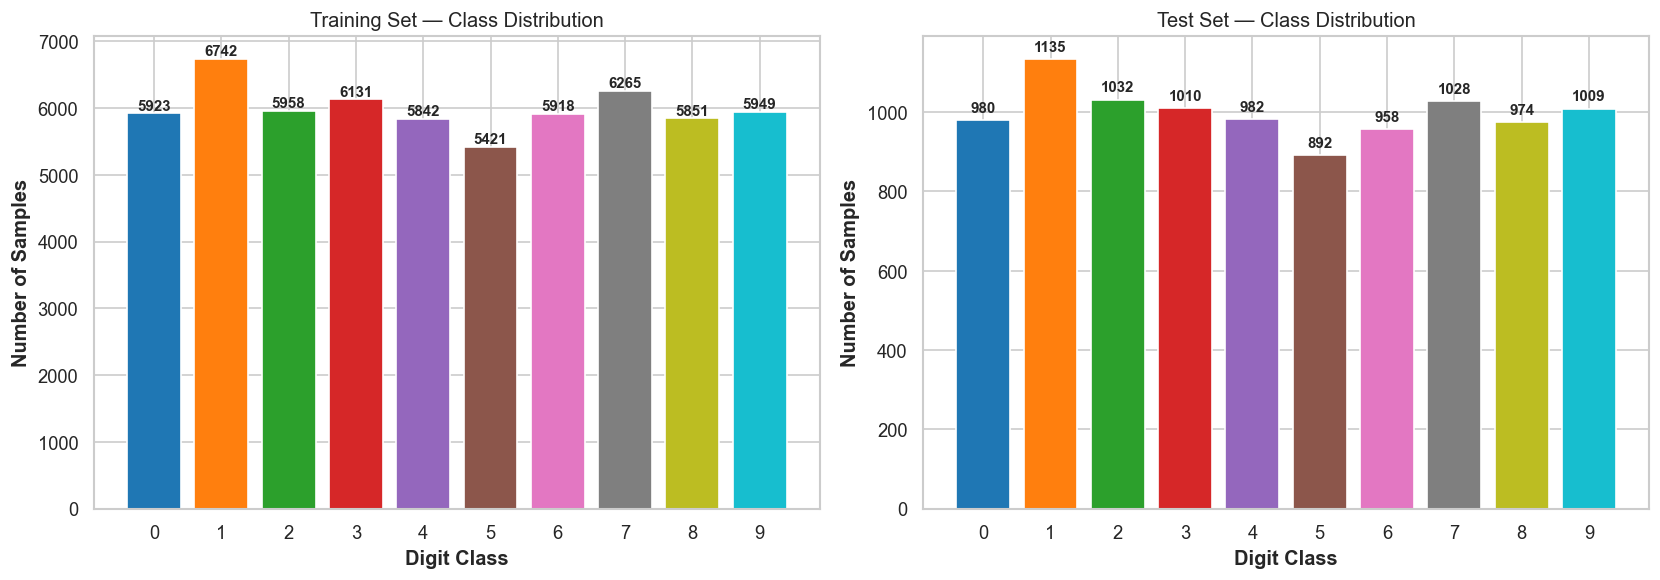

Training counts per class:
0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949

Is balanced? Min=5421, Max=6742, Range=1321


In [4]:
# ── 3.2  Class Distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts  = pd.Series(y_test).value_counts().sort_index()

axes[0].bar(train_counts.index, train_counts.values, color=sns.color_palette('tab10', 10))
axes[0].set_xlabel('Digit Class')
axes[0].set_ylabel('Number of Samples')
axes[0].set_title('Training Set — Class Distribution')
axes[0].set_xticks(range(10))
for i, v in enumerate(train_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=9, fontweight='bold')

axes[1].bar(test_counts.index, test_counts.values, color=sns.color_palette('tab10', 10))
axes[1].set_xlabel('Digit Class')
axes[1].set_ylabel('Number of Samples')
axes[1].set_title('Test Set — Class Distribution')
axes[1].set_xticks(range(10))
for i, v in enumerate(test_counts.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("Training counts per class:")
print(train_counts.to_string())
print(f"\nIs balanced? Min={train_counts.min()}, Max={train_counts.max()}, "
      f"Range={train_counts.max()-train_counts.min()}")

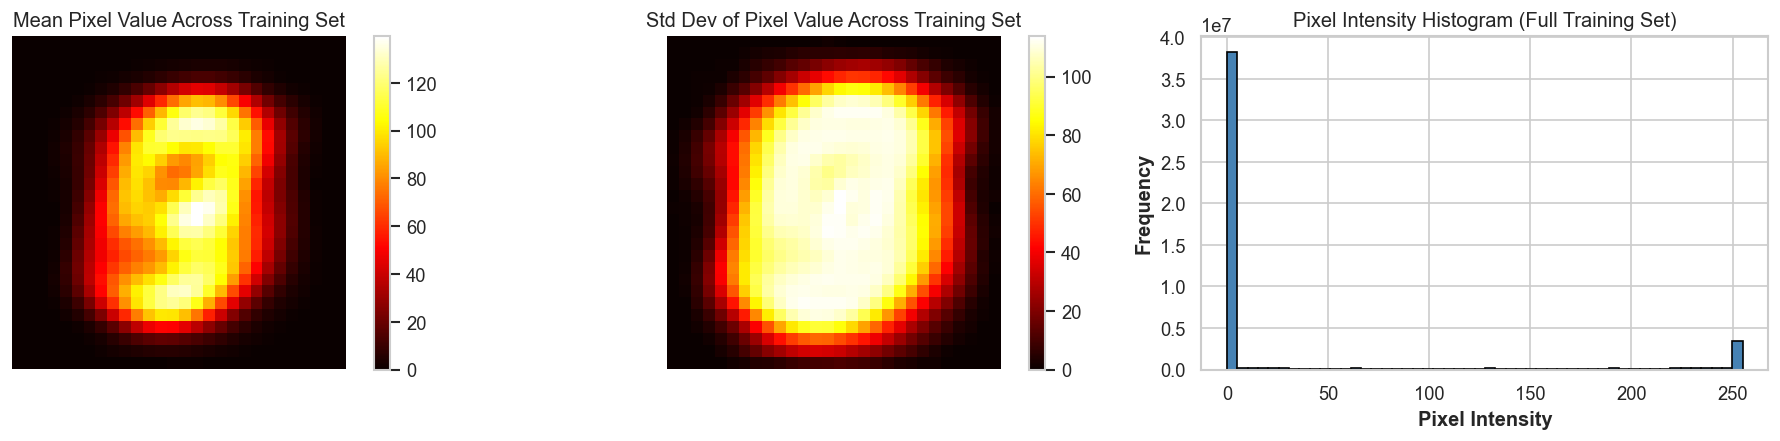

In [5]:
# ── 3.3  Pixel Statistics EDA ───────────────────────────────────────────────
# Flatten for stats
X_flat = X_train_raw.reshape(60000, -1).astype(float)  # (60000, 784)

pixel_means = X_flat.mean(axis=0).reshape(28, 28)
pixel_stds  = X_flat.std(axis=0).reshape(28, 28)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

im0 = axes[0].imshow(pixel_means, cmap='hot')
axes[0].set_title('Mean Pixel Value Across Training Set')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(pixel_stds, cmap='hot')
axes[1].set_title('Std Dev of Pixel Value Across Training Set')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1])

axes[2].hist(X_flat.flatten(), bins=50, color='steelblue', edgecolor='black')
axes[2].set_xlabel('Pixel Intensity')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Pixel Intensity Histogram (Full Training Set)')

plt.tight_layout()
plt.show()

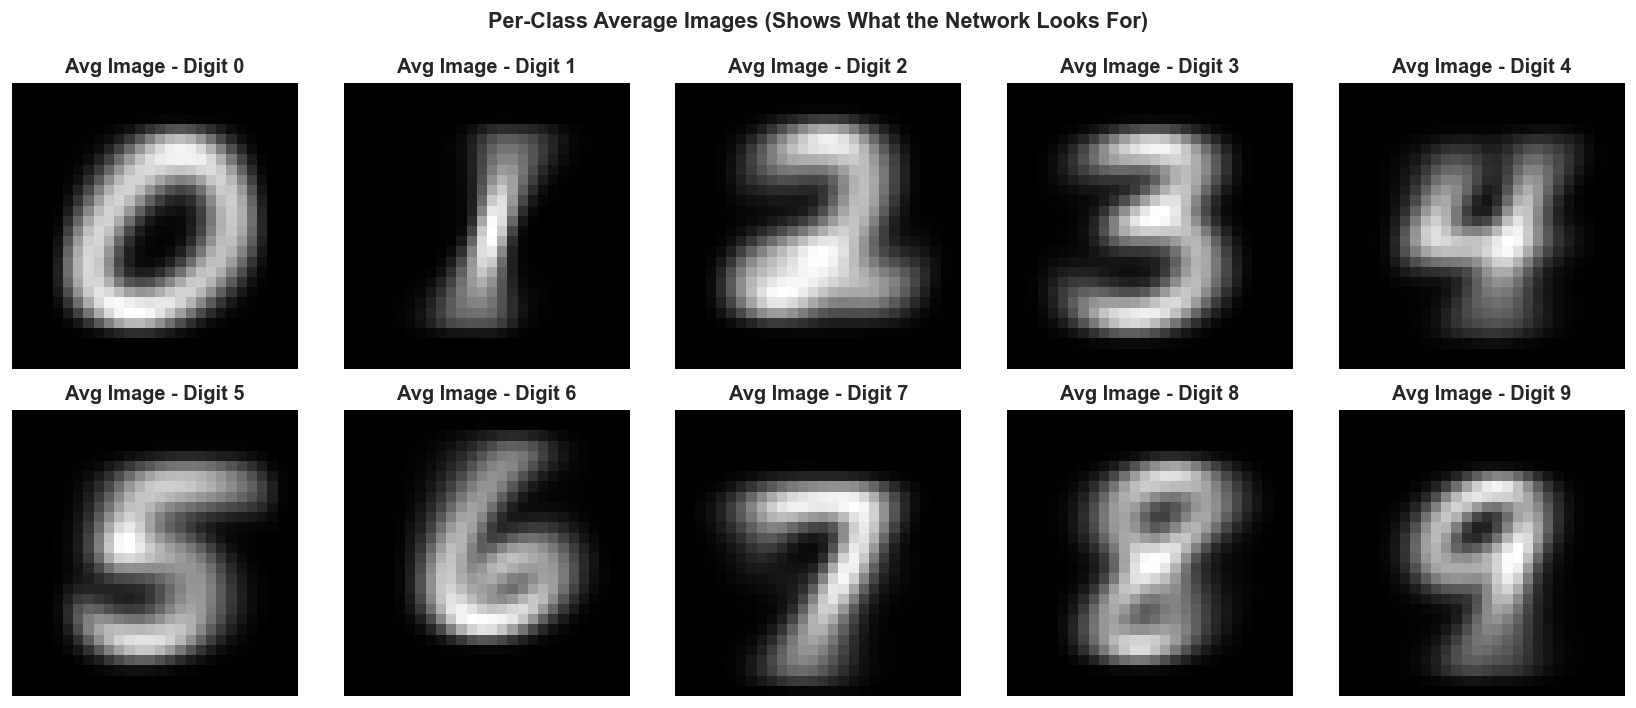

In [6]:
# ── 3.4  Per-class Average Image ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()
for digit in range(10):
    mask = y_train == digit
    avg_img = X_train_raw[mask].mean(axis=0)
    axes[digit].imshow(avg_img, cmap='gray')
    axes[digit].set_title(f'Avg Image - Digit {digit}', fontweight='bold')
    axes[digit].axis('off')

plt.suptitle('Per-Class Average Images (Shows What the Network Looks For)',
             fontsize=13, fontweight='bold')
plt.subplots_adjust(
    top=0.88,           # space for suptitle
    wspace=0.10,
    hspace=0.25
)
plt.tight_layout()
plt.show()

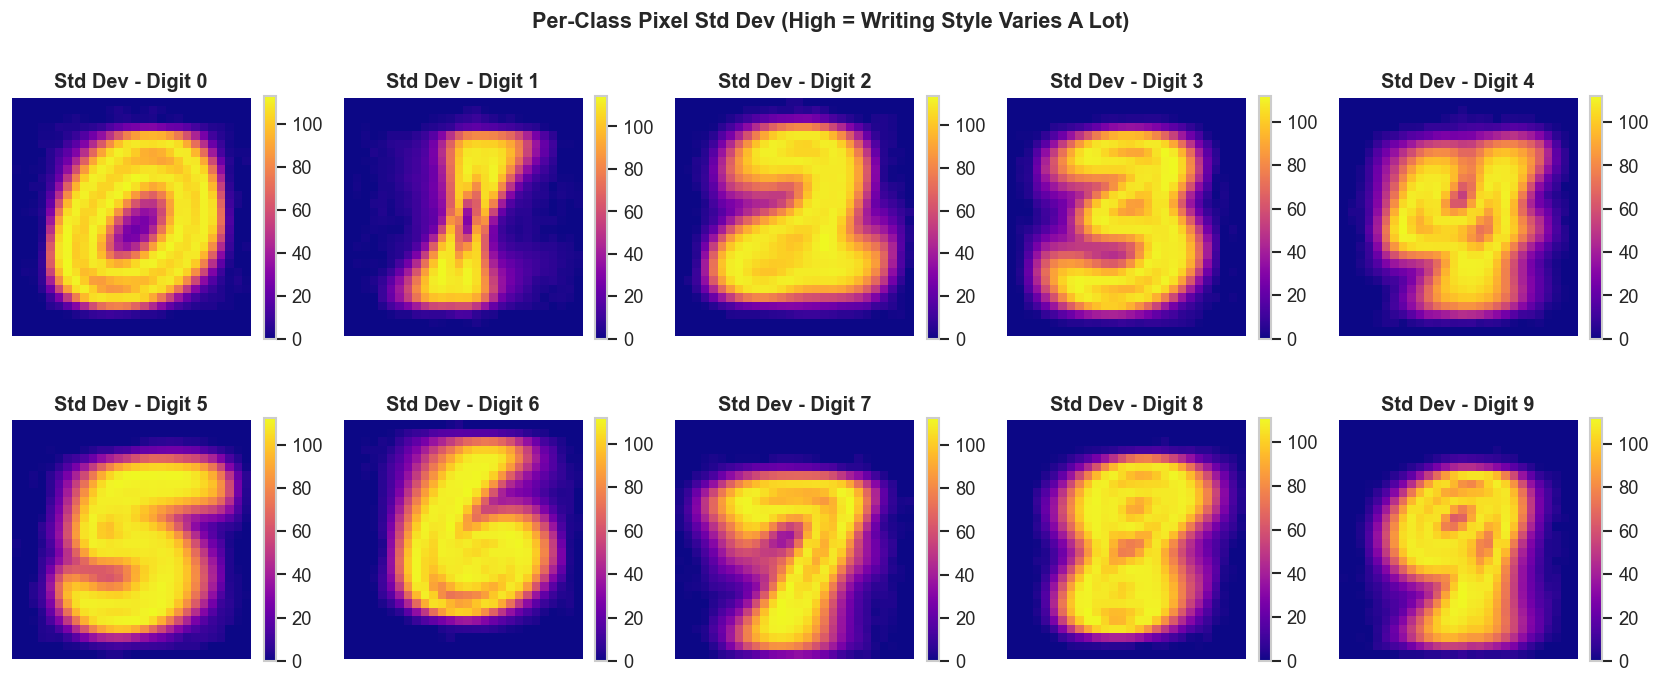

In [7]:
# ── 3.5  Image Variance Exploration - Easy vs Hard Digits ────────────────────
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()
for digit in range(10):
    mask = y_train == digit
    std_img = X_train_raw[mask].std(axis=0)
    im = axes[digit].imshow(std_img, cmap='plasma')
    axes[digit].set_title(f'Std Dev - Digit {digit}', fontweight='bold')
    axes[digit].axis('off')
    plt.colorbar(im, ax=axes[digit], fraction=0.046)

plt.suptitle('Per-Class Pixel Std Dev (High = Writing Style Varies A Lot)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## SECTION 4 - Preprocessing

In [8]:
# ── 4.1  Normalize pixels to [0, 1] ─────────────────────────────────────────
X_train_norm = X_train_raw.astype(np.float32) / 255.0
X_test_norm  = X_test_raw.astype(np.float32)  / 255.0

print("Before normalization: min={}, max={}".format(X_train_raw.min(), X_train_raw.max()))
print("After  normalization: min={:.3f}, max={:.3f}".format(X_train_norm.min(), X_train_norm.max()))

# ── 4.2  Flatten for classical ML ────────────────────────────────────────────
X_train_flat = X_train_norm.reshape(60000, -1)   # (60000, 784)
X_test_flat  = X_test_norm.reshape(10000, -1)    # (10000, 784)

print("\nFlat training shape :", X_train_flat.shape)
print("Flat test shape     :", X_test_flat.shape)

# ── 4.3  For CNN: add channel dimension ──────────────────────────────────────
X_train_cnn = X_train_norm[:, :, :, np.newaxis]  # (60000, 28, 28, 1)
X_test_cnn  = X_test_norm[:, :, :, np.newaxis]
print("\nCNN training shape  :", X_train_cnn.shape)

# ── 4.4  One-hot encoding for Keras ──────────────────────────────────────────
if TF_AVAILABLE:
    y_train_ohe = to_categorical(y_train, num_classes=10)
    y_test_ohe  = to_categorical(y_test,  num_classes=10)
    print("\nOne-hot label shape :", y_train_ohe.shape)
    print("Example (label=5)  :", y_train_ohe[np.where(y_train==5)[0][0]])

print("\nPreprocessing complete!")

Before normalization: min=0, max=255
After  normalization: min=0.000, max=1.000

Flat training shape : (60000, 784)
Flat test shape     : (10000, 784)

CNN training shape  : (60000, 28, 28, 1)

One-hot label shape : (60000, 10)
Example (label=5)  : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]

Preprocessing complete!


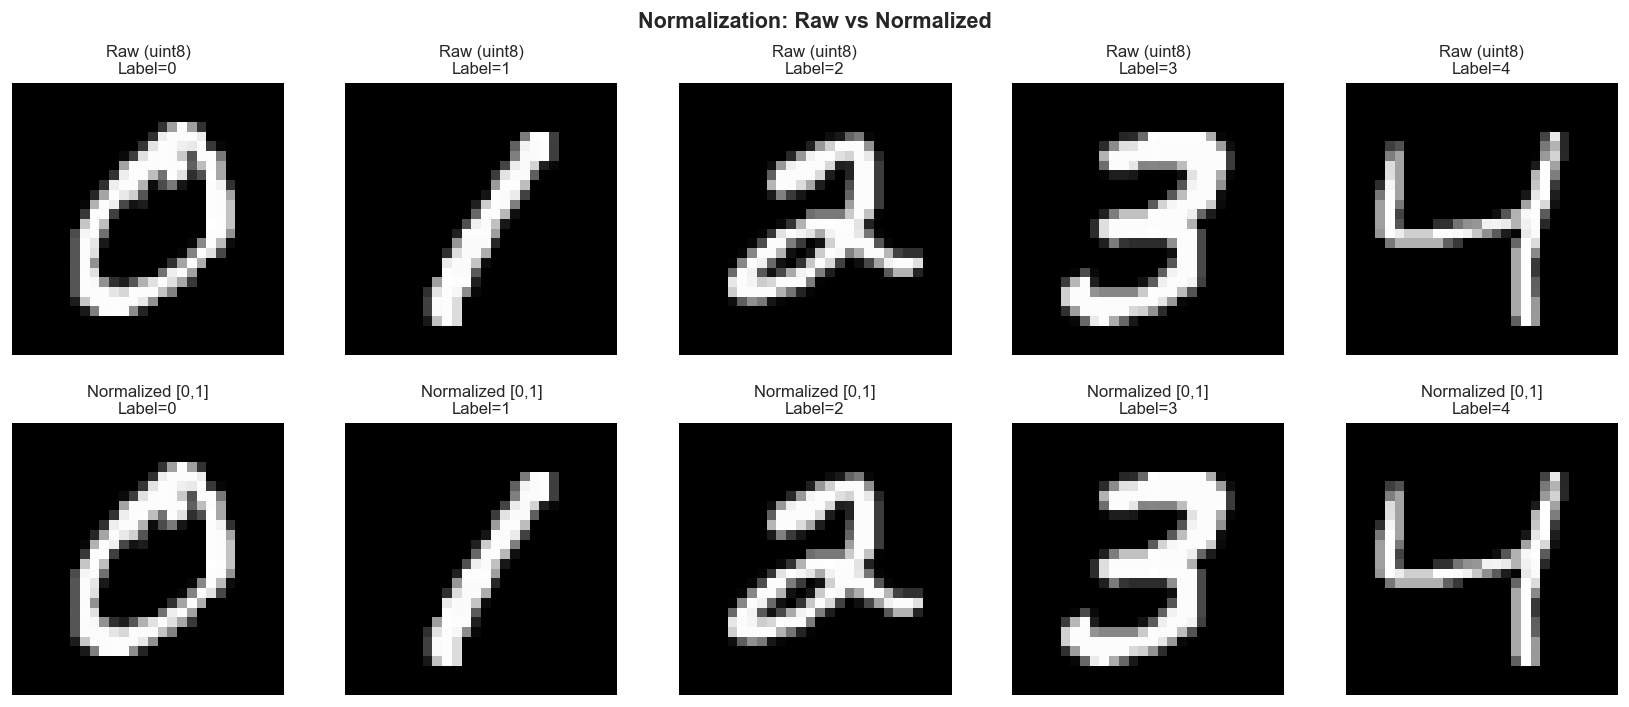

In [9]:
# ── 4.5  Visualize Before vs After Normalization ─────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
idxs = [np.where(y_train==i)[0][0] for i in range(5)]
for col, idx in enumerate(idxs):
    axes[0, col].imshow(X_train_raw[idx], cmap='gray', vmin=0, vmax=255)
    axes[0, col].set_title(f'Raw (uint8)\nLabel={y_train[idx]}', fontsize=10)
    axes[0, col].axis('off')

    axes[1, col].imshow(X_train_norm[idx], cmap='gray', vmin=0, vmax=1)
    axes[1, col].set_title(f'Normalized [0,1]\nLabel={y_train[idx]}', fontsize=10)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Before', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('After', fontsize=12, fontweight='bold')
plt.suptitle('Normalization: Raw vs Normalized', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(
    top=0.88,           # space for suptitle
    wspace=0.10,
    hspace=0.25
)
plt.show()

## SECTION 5 - Feature Engineering

Running PCA...
Original features  : 784
After PCA (50 comp): 50
Variance explained : 82.5%


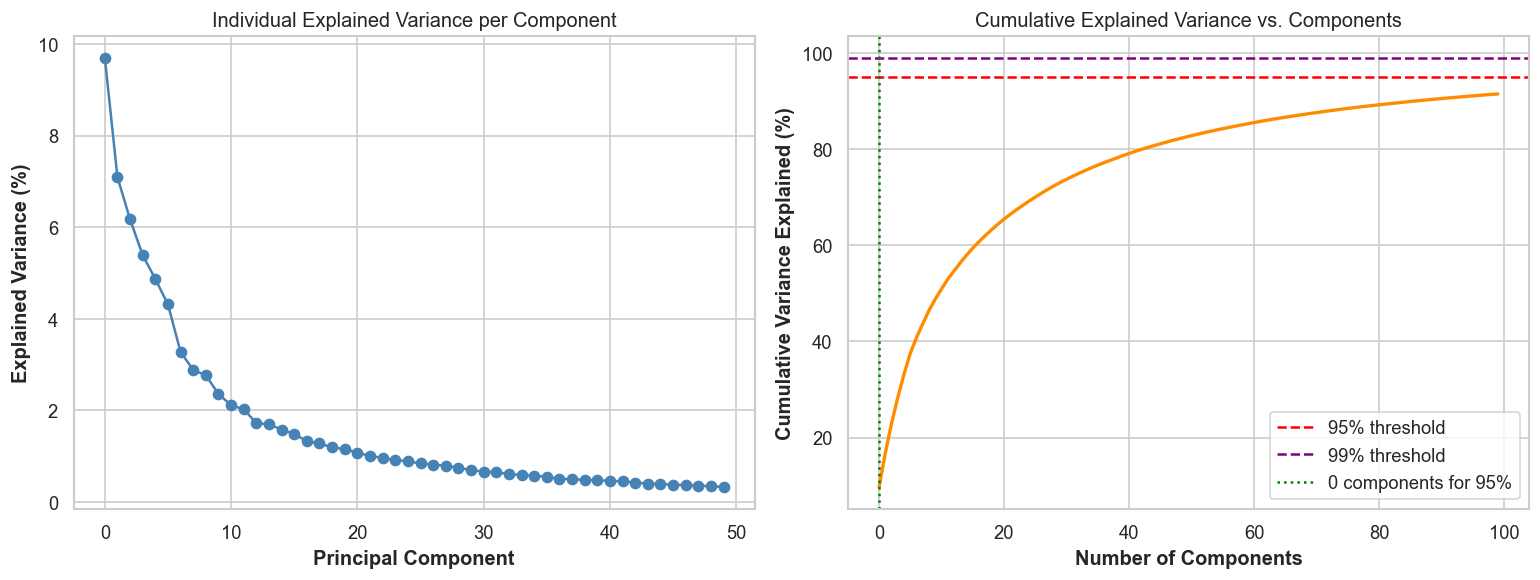

Components needed for 95% variance: 0


In [10]:
# ── 5.1  PCA — Reduce 784 → 50 dimensions ───────────────────────────────────
print("Running PCA...")
pca = PCA(n_components=50, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca  = pca.transform(X_test_flat)

print(f"Original features  : 784")
print(f"After PCA (50 comp): {X_train_pca.shape[1]}")
print(f"Variance explained : {pca.explained_variance_ratio_.sum()*100:.1f}%")

# ── Plot cumulative explained variance ──────────────────────────────────────
pca_full = PCA(n_components=100, random_state=SEED)
pca_full.fit(X_train_flat)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(pca_full.explained_variance_ratio_[:50] * 100, 'o-', color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Individual Explained Variance per Component')

axes[1].plot(cumvar * 100, color='darkorange', linewidth=2)
axes[1].axhline(95, color='red', linestyle='--', label='95% threshold')
axes[1].axhline(99, color='purple', linestyle='--', label='99% threshold')
idx_95 = np.argmax(cumvar >= 0.95)
axes[1].axvline(idx_95, color='green', linestyle=':', label=f'{idx_95} components for 95%')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained (%)')
axes[1].set_title('Cumulative Explained Variance vs. Components')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Components needed for 95% variance: {idx_95}")

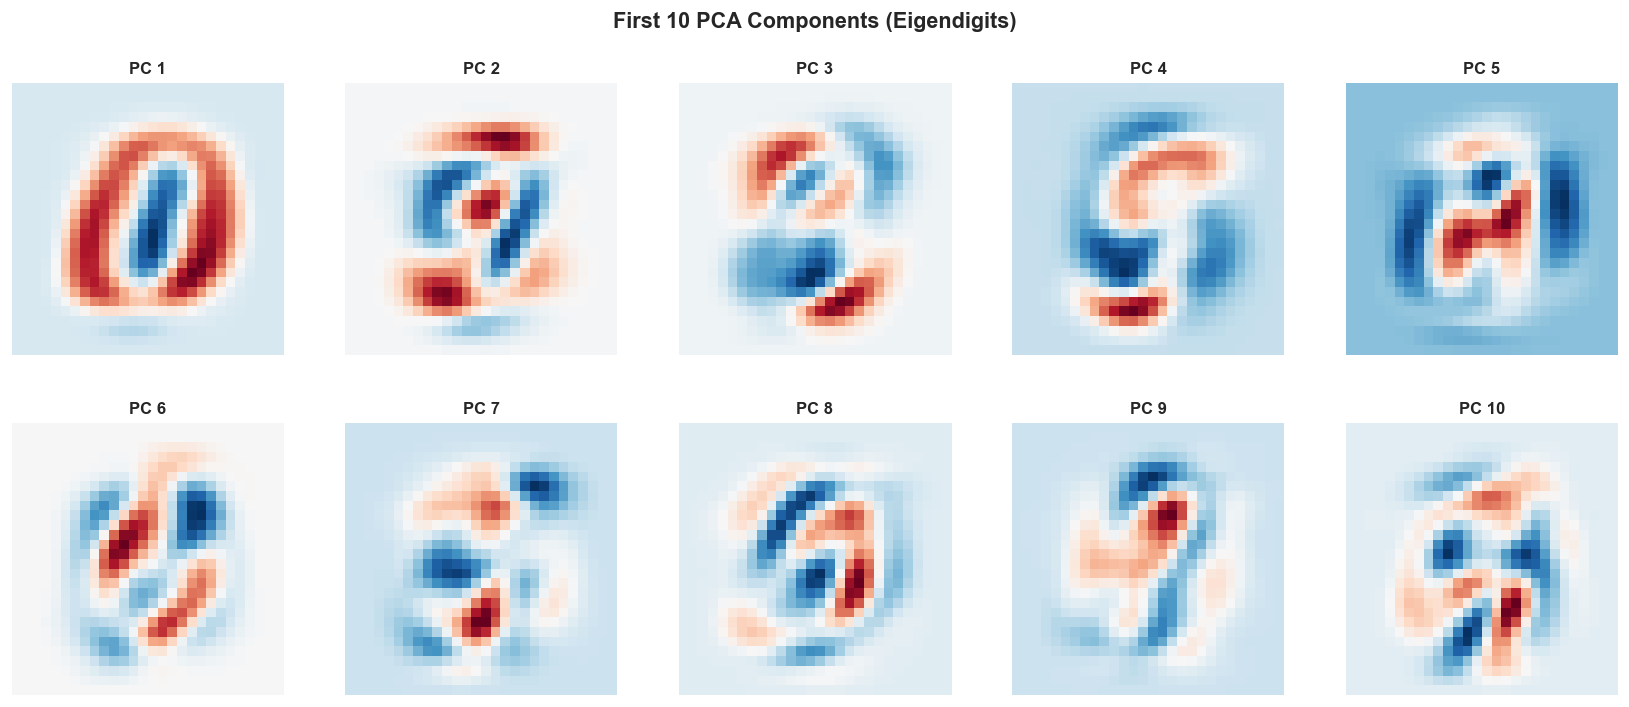

In [11]:
# ── 5.2  Visualize PCA Components (Eigendigits) ──────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flatten()):
    eigendigit = pca.components_[i].reshape(28, 28)
    ax.imshow(eigendigit, cmap='RdBu_r')
    ax.set_title(f'PC {i+1}', fontweight='bold', fontsize=10)
    ax.axis('off')

plt.suptitle('First 10 PCA Components (Eigendigits)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.88, wspace=0.10, hspace=0.25
)
plt.show()

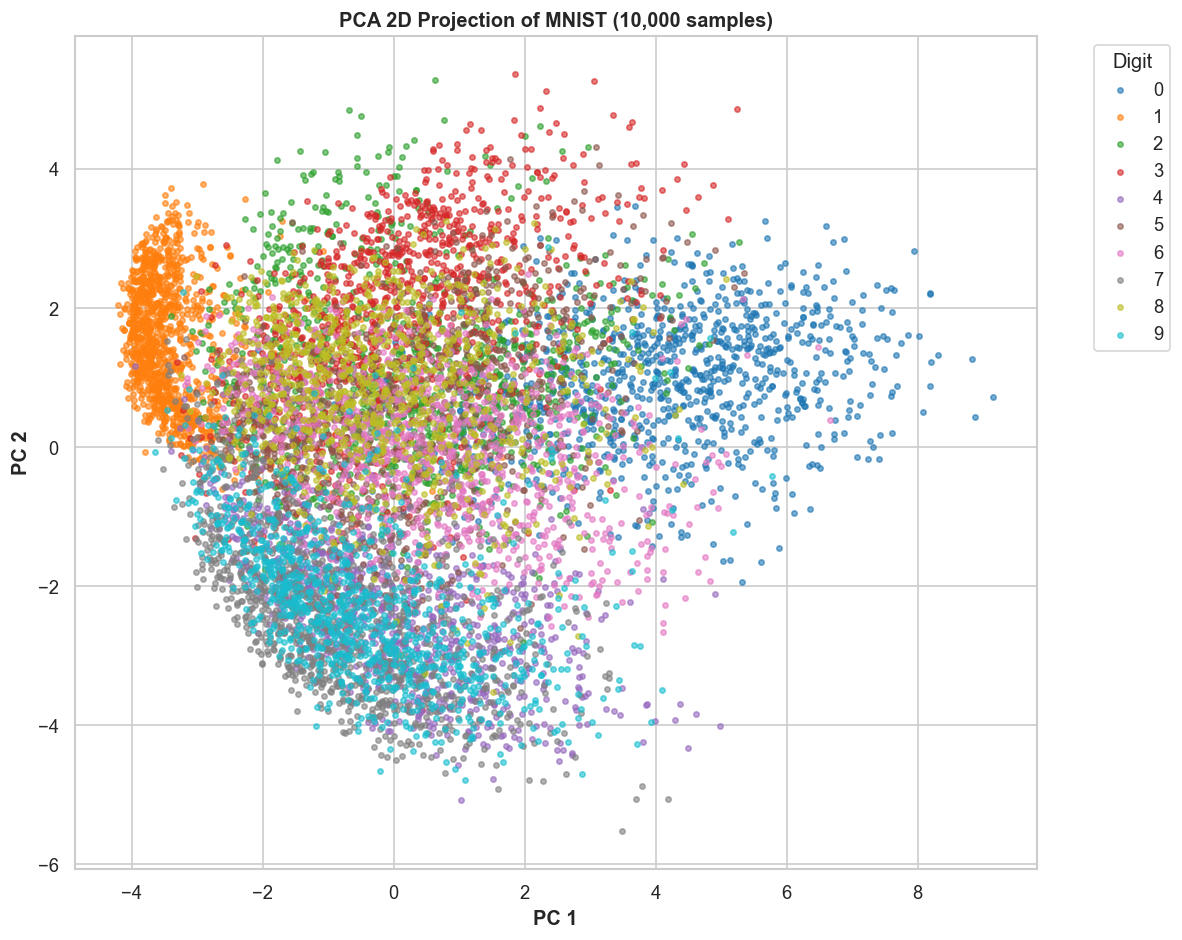

In [12]:
# ── 5.3  PCA 2D Visualization ────────────────────────────────────────────────
pca2 = PCA(n_components=2, random_state=SEED)
# Use only 10k samples for speed
X_2d = pca2.fit_transform(X_train_flat[:10000])
y_sub = y_train[:10000]

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, 10))
for digit in range(10):
    mask = y_sub == digit
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=[colors[digit]], label=str(digit),
               alpha=0.6, s=10, rasterized=True)

ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_title('PCA 2D Projection of MNIST (10,000 samples)', fontweight='bold')
ax.legend(title='Digit', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Running t-SNE (may take ~60 seconds)...
t-SNE done in 7.2s


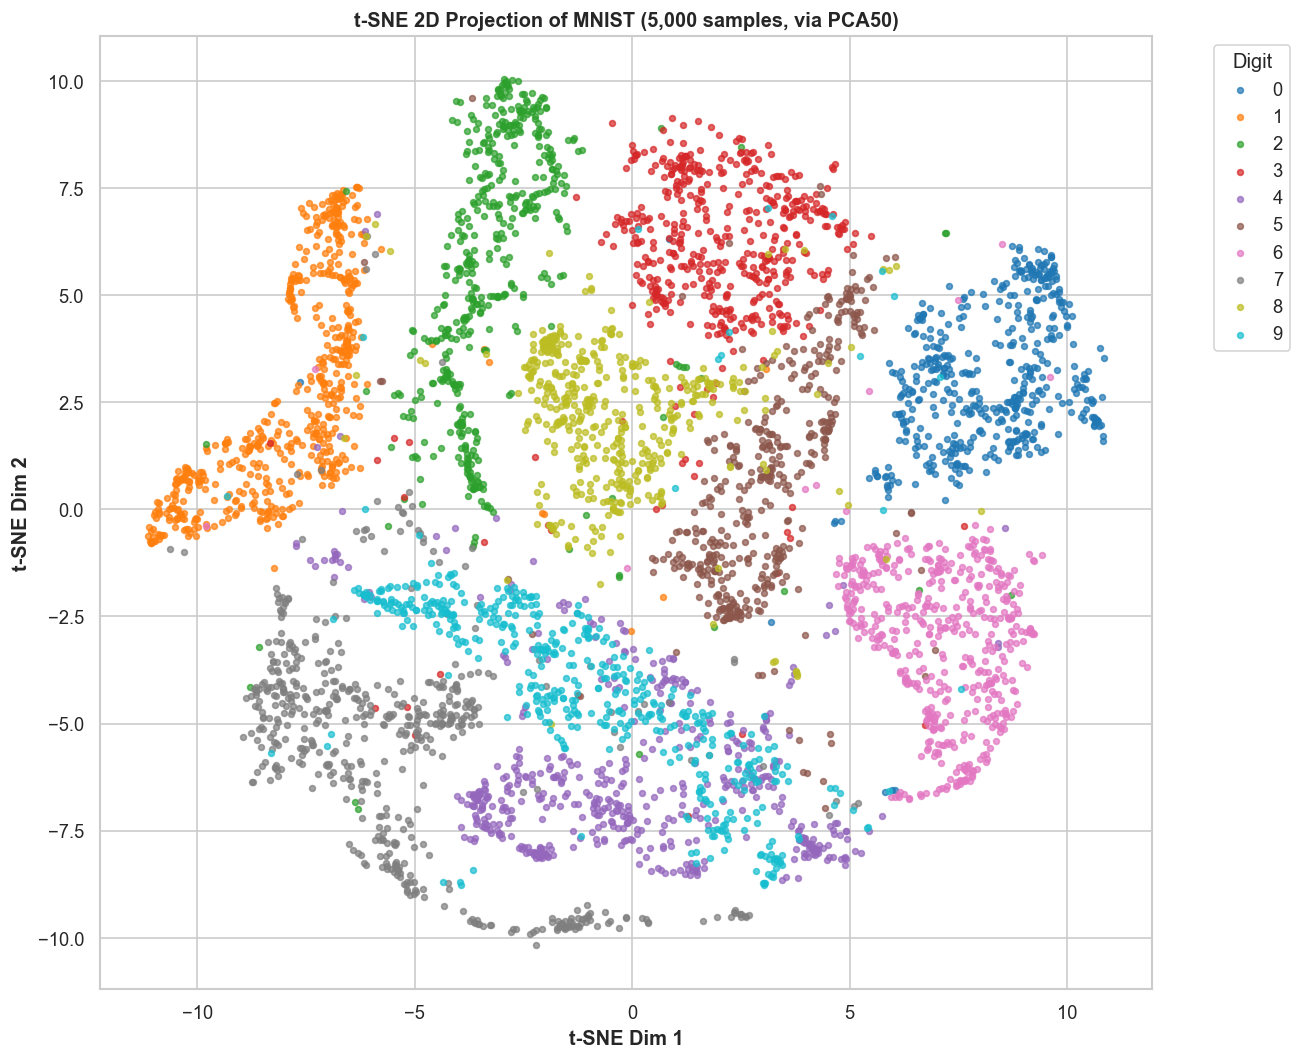

Notice: Each digit forms a clear cluster → MNIST is well-separable!


In [13]:
# ── 5.4  t-SNE 2D Visualization (more powerful than PCA) ────────────────────
print("Running t-SNE (may take ~60 seconds)...")
t0 = time.time()
tsne = TSNE(n_components=2, perplexity=30, n_iter=300, random_state=SEED, n_jobs=-1)
X_tsne = tsne.fit_transform(X_train_pca[:5000])  # Use PCA features for speed
y_tsne = y_train[:5000]
print(f"t-SNE done in {time.time()-t0:.1f}s")

fig, ax = plt.subplots(figsize=(11, 9))
for digit in range(10):
    mask = y_tsne == digit
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=[colors[digit]], label=str(digit),
               alpha=0.7, s=12, rasterized=True)

ax.set_xlabel('t-SNE Dim 1')
ax.set_ylabel('t-SNE Dim 2')
ax.set_title('t-SNE 2D Projection of MNIST (5,000 samples, via PCA50)', fontweight='bold')
ax.legend(title='Digit', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
print("Notice: Each digit forms a clear cluster → MNIST is well-separable!")

## SECTION 6 - Classical Machine Learning Models

In [14]:
# ── Use 10k training samples for speed (use 60k for best accuracy) ──────────
N_TRAIN_ML = 10000
Xm_train = X_train_flat[:N_TRAIN_ML]
ym_train = y_train[:N_TRAIN_ML]
Xm_test  = X_test_flat          # Full 10k test
ym_test  = y_test

# Also PCA features for faster SVM
pca50 = PCA(n_components=50, random_state=SEED)
Xm_train_pca = pca50.fit_transform(Xm_train)
Xm_test_pca  = pca50.transform(Xm_test)

print(f"ML training set  : {Xm_train.shape}")
print(f"ML test set      : {Xm_test.shape}")

ML training set  : (10000, 784)
ML test set      : (10000, 784)


In [15]:
# ──────────────────────────────────────────────────────────────────────────────
#  Helper: Train, evaluate, and store results
# ──────────────────────────────────────────────────────────────────────────────
results = {}   # Will collect all model results

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, use_pca=False):
    label = name + (' (PCA50)' if use_pca else '')
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0

    t0 = time.time()
    y_pred = model.predict(X_te)
    inf_time = time.time() - t0

    acc = accuracy_score(y_te, y_pred)
    results[label] = {
        'accuracy': acc,
        'train_time': train_time,
        'inf_time': inf_time,
        'y_pred': y_pred,
        'model': model
    }
    print(f"  {label:<35} Acc={acc*100:.2f}%  Train={train_time:.1f}s  Infer={inf_time:.2f}s")
    return model, y_pred

print("Training classical ML models...")
print("-" * 75)

Training classical ML models...
---------------------------------------------------------------------------


In [16]:
# ── 6.1  Logistic Regression ─────────────────────────────────────────────────
print("\n[1] Logistic Regression")
lr_model, lr_pred = evaluate_model(
    'Logistic Regression', 
    LogisticRegression(max_iter=500, random_state=SEED, solver='saga', n_jobs=-1),
    Xm_train, ym_train, Xm_test, ym_test
)


[1] Logistic Regression
  Logistic Regression                 Acc=90.48%  Train=166.8s  Infer=0.01s


In [17]:
# ── 6.2  K-Nearest Neighbors ─────────────────────────────────────────────────
print("\n[2] K-Nearest Neighbors (k=5)")
knn_model, knn_pred = evaluate_model(
    'KNN k=5',
    KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    Xm_train, ym_train, Xm_test, ym_test
)


[2] K-Nearest Neighbors (k=5)
  KNN k=5                             Acc=94.42%  Train=0.0s  Infer=1.09s


In [18]:
# ── 6.3  Decision Tree ───────────────────────────────────────────────────────
print("\n[3] Decision Tree")
dt_model, dt_pred = evaluate_model(
    'Decision Tree',
    DecisionTreeClassifier(max_depth=20, random_state=SEED),
    Xm_train, ym_train, Xm_test, ym_test
)


[3] Decision Tree
  Decision Tree                       Acc=80.43%  Train=2.4s  Infer=0.01s


In [19]:
# ── 6.4  Random Forest ───────────────────────────────────────────────────────
print("\n[4] Random Forest")
rf_model, rf_pred = evaluate_model(
    'Random Forest',
    RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED),
    Xm_train, ym_train, Xm_test, ym_test
)


[4] Random Forest
  Random Forest                       Acc=95.03%  Train=1.1s  Infer=0.09s


In [20]:
# ── 6.5  Naive Bayes ────────────────────────────────────────────────────────
print("\n[5] Gaussian Naive Bayes")
nb_model, nb_pred = evaluate_model(
    'Naive Bayes',
    GaussianNB(),
    Xm_train, ym_train, Xm_test, ym_test
)


[5] Gaussian Naive Bayes
  Naive Bayes                         Acc=57.38%  Train=0.1s  Infer=0.87s


In [21]:
# ── 6.6  SVM (on PCA features for speed) ────────────────────────────────────
print("\n[6] SVM RBF (on PCA50 features)")
svm_model, svm_pred = evaluate_model(
    'SVM RBF',
    SVC(kernel='rbf', C=10, gamma='scale', random_state=SEED),
    Xm_train_pca, ym_train, Xm_test_pca, ym_test,
    use_pca=True
)


[6] SVM RBF (on PCA50 features)
  SVM RBF (PCA50)                     Acc=97.09%  Train=1.2s  Infer=3.36s


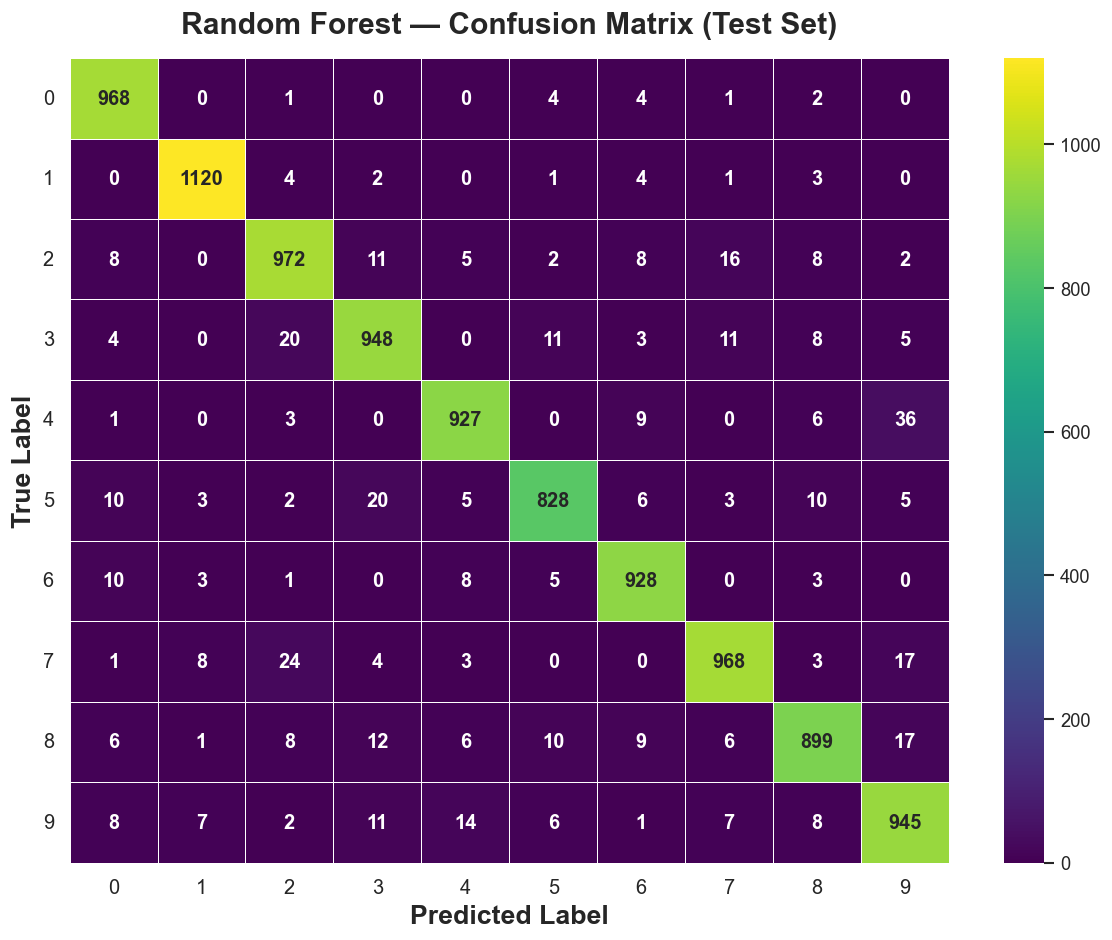

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(ym_test, best_ml_pred)

classes = [str(i) for i in range(10)]

# Custom formatting for annotations
def format_annotation(value):
    if float(value).is_integer():
        return f"{int(value)}"
    return f"{value:.1f}"

# Create formatted annotation matrix
annot_matrix = np.array([
    [format_annotation(val) for val in row]
    for row in cm
])

# Plot
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=annot_matrix,
    fmt='',
    cmap='viridis',          # Try: viridis, magma, cividis
    xticklabels=classes,
    yticklabels=classes,
    cbar=True,
    linewidths=0.5,
    linecolor='white',
    annot_kws={
        "size": 12,
        "fontweight": "bold"
    }
)

# Labels and title
plt.xlabel(
    'Predicted Label',
    fontsize=16,
    fontweight='bold'
)

plt.ylabel(
    'True Label',
    fontsize=16,
    fontweight='bold'
)

plt.title(
    'Random Forest — Confusion Matrix (Test Set)',
    fontsize=18,
    fontweight='bold',
    pad=15
)

# Tick styling
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)

plt.tight_layout()
plt.show()

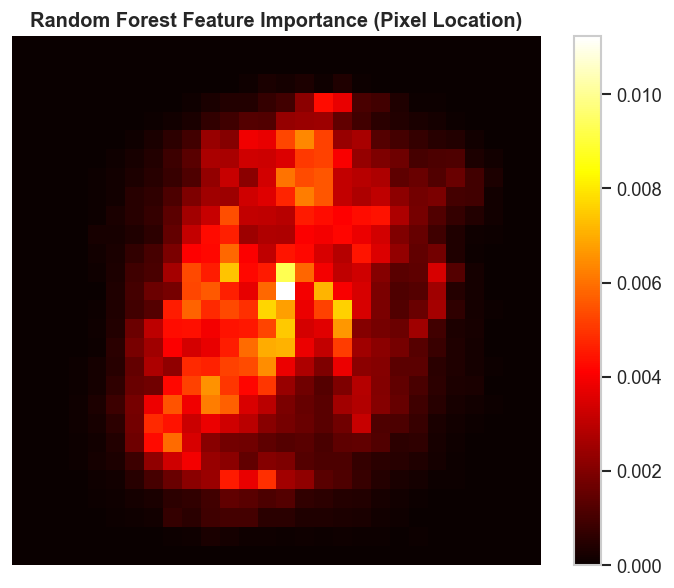

Bright pixels = more important for classification


In [23]:
# ── 6.8  Feature Importance (Random Forest) ─────────────────────────────────
importances = rf_model.feature_importances_.reshape(28, 28)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(importances, cmap='hot')
ax.set_title('Random Forest Feature Importance (Pixel Location)', fontweight='bold')
ax.axis('off')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
print("Bright pixels = more important for classification")

## ─────────────────────────────────────────
## SECTION 7 — Deep Learning: MLP from Scratch (NumPy)
## ─────────────────────────────────────────
Build a neural network from scratch — only NumPy, no frameworks!

In [24]:
class NumpyMLP:
    """
    2-layer MLP built entirely with NumPy.
    Architecture: 784 → 256 → 128 → 10
    """
    def __init__(self, lr=0.01, epochs=20, batch_size=256):
        self.lr, self.epochs, self.batch_size = lr, epochs, batch_size
        # Xavier initialization
        self.W1 = np.random.randn(784, 256) * np.sqrt(2/784)
        self.b1 = np.zeros((1, 256))
        self.W2 = np.random.randn(256, 128) * np.sqrt(2/256)
        self.b2 = np.zeros((1, 128))
        self.W3 = np.random.randn(128, 10) * np.sqrt(2/128)
        self.b3 = np.zeros((1, 10))
        self.history = {'loss': [], 'acc': []}

    def relu(self, z):       return np.maximum(0, z)
    def relu_d(self, z):     return (z > 0).astype(float)
    def softmax(self, z):
        e = np.exp(z - z.max(axis=1, keepdims=True))
        return e / e.sum(axis=1, keepdims=True)

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.relu(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.relu(self.z2)
        self.z3 = self.a2 @ self.W3 + self.b3
        self.a3 = self.softmax(self.z3)
        return self.a3

    def cross_entropy(self, y_pred, y_true):
        n = y_true.shape[0]
        return -np.sum(y_true * np.log(y_pred + 1e-9)) / n

    def backward(self, X, y_true):
        n = X.shape[0]
        dz3 = (self.a3 - y_true) / n
        dW3 = self.a2.T @ dz3
        db3 = dz3.sum(axis=0, keepdims=True)

        da2 = dz3 @ self.W3.T
        dz2 = da2 * self.relu_d(self.z2)
        dW2 = self.a1.T @ dz2
        db2 = dz2.sum(axis=0, keepdims=True)

        da1 = dz2 @ self.W2.T
        dz1 = da1 * self.relu_d(self.z1)
        dW1 = X.T @ dz1
        db1 = dz1.sum(axis=0, keepdims=True)

        # SGD update
        for W, dW in [(self.W1,dW1),(self.W2,dW2),(self.W3,dW3)]:
            W -= self.lr * dW
        for b, db in [(self.b1,db1),(self.b2,db2),(self.b3,db3)]:
            b -= self.lr * db

    def fit(self, X, y):
        y_ohe = np.eye(10)[y]
        n = X.shape[0]
        for epoch in range(self.epochs):
            idx = np.random.permutation(n)
            X, y_ohe = X[idx], y_ohe[idx]
            ep_loss = []
            for i in range(0, n, self.batch_size):
                Xb = X[i:i+self.batch_size]
                yb = y_ohe[i:i+self.batch_size]
                out = self.forward(Xb)
                ep_loss.append(self.cross_entropy(out, yb))
                self.backward(Xb, yb)
            loss = np.mean(ep_loss)
            preds = self.predict(X)
            acc   = (preds == y[idx]).mean()
            self.history['loss'].append(loss)
            self.history['acc'].append(acc)
            if (epoch+1) % 5 == 0:
                print(f"  Epoch {epoch+1:3d}/{self.epochs}  loss={loss:.4f}  train_acc={acc*100:.2f}%")

    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)

# ── Train ────────────────────────────────────────────────────────────────────
np.random.seed(SEED)
print("Training NumPy MLP (784→256→128→10)...")
numpy_mlp = NumpyMLP(lr=0.05, epochs=20, batch_size=256)
numpy_mlp.fit(X_train_flat[:20000], y_train[:20000])

np_pred = numpy_mlp.predict(X_test_flat)
np_acc  = accuracy_score(y_test, np_pred)
print(f"\nTest accuracy (NumPy MLP): {np_acc*100:.2f}%")
results['NumPy MLP (Scratch)'] = {'accuracy': np_acc, 'y_pred': np_pred,
                                   'train_time': 0, 'inf_time': 0}

Training NumPy MLP (784→256→128→10)...
  Epoch   5/20  loss=0.3031  train_acc=9.83%
  Epoch  10/20  loss=0.2193  train_acc=10.06%
  Epoch  15/20  loss=0.1777  train_acc=9.73%
  Epoch  20/20  loss=0.1426  train_acc=9.88%

Test accuracy (NumPy MLP): 94.42%


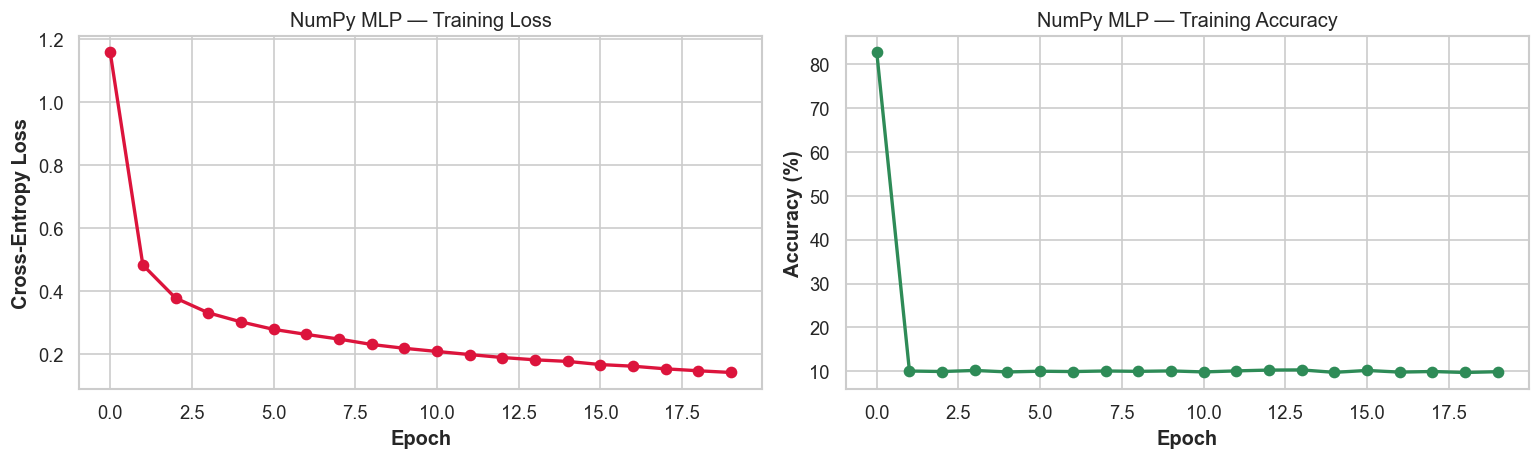

In [25]:
# ── 7.1  Training Curves (NumPy MLP) ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(numpy_mlp.history['loss'], 'o-', color='crimson', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('NumPy MLP — Training Loss')

axes[1].plot(np.array(numpy_mlp.history['acc'])*100, 'o-', color='seagreen', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('NumPy MLP — Training Accuracy')

plt.tight_layout()
plt.show()

## ─────────────────────────────────────────
## SECTION 8 — Deep Learning: MLP with Keras
## ─────────────────────────────────────────

In [26]:
if TF_AVAILABLE:
    tf.random.set_seed(SEED)

    # ── Build MLP ────────────────────────────────────────────────────────────
    def build_mlp():
        model = keras.Sequential([
            layers.Input(shape=(784,)),
            layers.Dense(512, activation='relu',
                         kernel_regularizer=regularizers.l2(1e-4)),
            layers.BatchNormalization(),
            layers.Dropout(0.3),
            layers.Dense(256, activation='relu',
                         kernel_regularizer=regularizers.l2(1e-4)),
            layers.BatchNormalization(),
            layers.Dropout(0.3),
            layers.Dense(128, activation='relu'),
            layers.Dense(10, activation='softmax')
        ])
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=1e-3),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        return model

    keras_mlp = build_mlp()
    keras_mlp.summary()
else:
    print("TensorFlow not available — skipping this cell")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 570,506 (2.18 MB)

 Trainable params: 568,970 (2.17 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [27]:
if TF_AVAILABLE:
    cb_list = [
        callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
        callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=0)
    ]

    t0 = time.time()
    history_mlp = keras_mlp.fit(
        X_train_flat, y_train_ohe,
        validation_split=0.1,
        epochs=30,
        batch_size=256,
        callbacks=cb_list,
        verbose=1
    )
    mlp_train_time = time.time() - t0

    mlp_pred = np.argmax(keras_mlp.predict(X_test_flat, verbose=0), axis=1)
    mlp_acc  = accuracy_score(y_test, mlp_pred)
    print(f"\nKeras MLP test accuracy: {mlp_acc*100:.2f}%  (trained in {mlp_train_time:.1f}s)")
    results['Keras MLP'] = {'accuracy': mlp_acc, 'y_pred': mlp_pred,
                             'train_time': mlp_train_time, 'inf_time': 0}
else:
    print("Skipping — TensorFlow not available")

Epoch 1/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9070 - loss: 0.3834 - val_accuracy: 0.9367 - val_loss: 0.3113 - learning_rate: 0.0010
Epoch 2/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9594 - loss: 0.2073 - val_accuracy: 0.9763 - val_loss: 0.1585 - learning_rate: 0.0010
Epoch 3/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9696 - loss: 0.1737 - val_accuracy: 0.9792 - val_loss: 0.1477 - learning_rate: 0.0010
Epoch 4/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9744 - loss: 0.1519 - val_accuracy: 0.9797 - val_loss: 0.1409 - learning_rate: 0.0010
Epoch 5/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9780 - loss: 0.1401 - val_accuracy: 0.9798 - val_loss: 0.1386 - learning_rate: 0.0010
Epoch 6/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9800 - loss: 0.1312 - val_accuracy: 0.9827 - val_loss: 0.1362 - learning_rate: 0.0010
Epoch 7/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9814 - loss: 0.1248 -

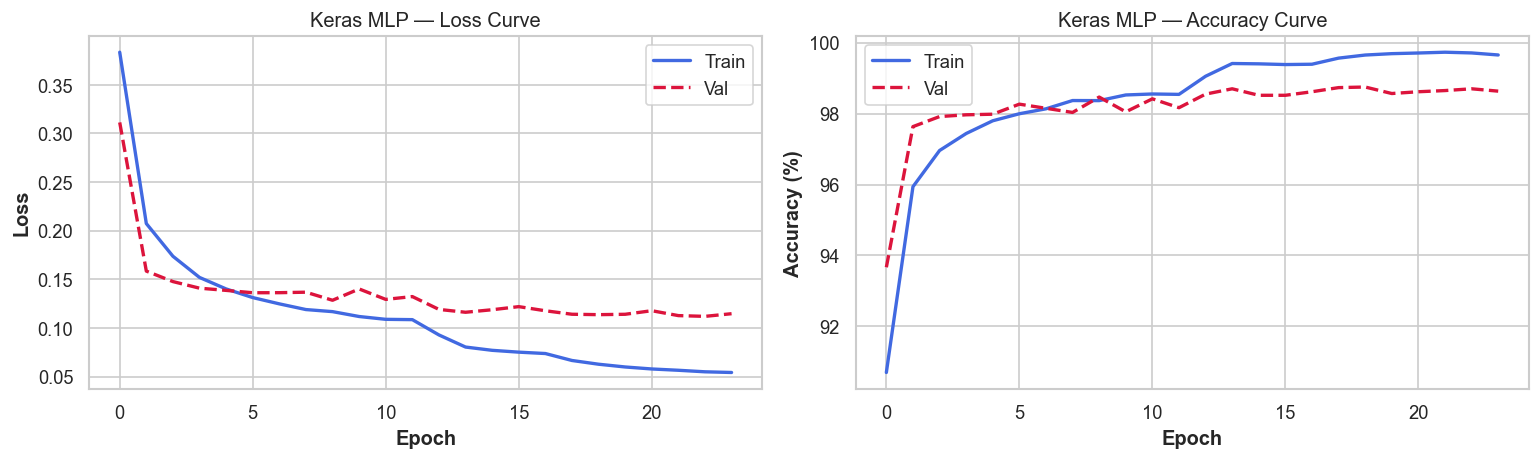

In [28]:
if TF_AVAILABLE and 'history_mlp' in dir():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history_mlp.history['loss'],     label='Train', linewidth=2, color='royalblue')
    axes[0].plot(history_mlp.history['val_loss'], label='Val',   linewidth=2, color='crimson', linestyle='--')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Keras MLP — Loss Curve')
    axes[0].legend()

    axes[1].plot(np.array(history_mlp.history['accuracy'])*100,     label='Train', linewidth=2, color='royalblue')
    axes[1].plot(np.array(history_mlp.history['val_accuracy'])*100, label='Val',   linewidth=2, color='crimson', linestyle='--')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Keras MLP — Accuracy Curve')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## ─────────────────────────────────────────
## SECTION 9 — Deep Learning: CNN with Keras
## ─────────────────────────────────────────
CNNs exploit the **spatial structure** of images — much better than MLP!

In [29]:
if TF_AVAILABLE:
    tf.random.set_seed(SEED)

    def build_cnn():
        model = keras.Sequential([
            layers.Input(shape=(28, 28, 1)),

            # Block 1
            layers.Conv2D(32, (3,3), padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.Conv2D(32, (3,3), padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPooling2D(2,2),
            layers.Dropout(0.25),

            # Block 2
            layers.Conv2D(64, (3,3), padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.Conv2D(64, (3,3), padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPooling2D(2,2),
            layers.Dropout(0.25),

            # Classifier head
            layers.Flatten(),
            layers.Dense(256, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.5),
            layers.Dense(10, activation='softmax')
        ])
        model.compile(
            optimizer=keras.optimizers.Adam(1e-3),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        return model

    keras_cnn = build_cnn()
    keras_cnn.summary()
else:
    print("TensorFlow not available — skipping")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 872,426 (3.33 MB)

 Trainable params: 871,530 (3.32 MB)

 Non-trainable params: 896 (3.50 KB)

In [30]:
if TF_AVAILABLE:
    cb_cnn = [
        callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
        callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=0)
    ]

    t0 = time.time()
    history_cnn = keras_cnn.fit(
        X_train_cnn, y_train_ohe,
        validation_split=0.1,
        epochs=30,
        batch_size=256,
        callbacks=cb_cnn,
        verbose=1
    )
    cnn_train_time = time.time() - t0

    cnn_pred = np.argmax(keras_cnn.predict(X_test_cnn, verbose=0), axis=1)
    cnn_acc  = accuracy_score(y_test, cnn_pred)
    print(f"\nKeras CNN test accuracy: {cnn_acc*100:.2f}%  (trained in {cnn_train_time:.1f}s)")
    results['Keras CNN'] = {'accuracy': cnn_acc, 'y_pred': cnn_pred,
                             'train_time': cnn_train_time, 'inf_time': 0}
else:
    print("Skipping — TensorFlow not available")

Epoch 1/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 55s 246ms/step - accuracy: 0.9382 - loss: 0.2025 - val_accuracy: 0.1050 - val_loss: 5.6620 - learning_rate: 0.0010
Epoch 2/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 51s 240ms/step - accuracy: 0.9794 - loss: 0.0651 - val_accuracy: 0.7913 - val_loss: 0.6361 - learning_rate: 0.0010
Epoch 3/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 51s 240ms/step - accuracy: 0.9856 - loss: 0.0476 - val_accuracy: 0.9858 - val_loss: 0.0523 - learning_rate: 0.0010
Epoch 4/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 53s 249ms/step - accuracy: 0.9877 - loss: 0.0385 - val_accuracy: 0.9910 - val_loss: 0.0285 - learning_rate: 0.0010
Epoch 5/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 54s 255ms/step - accuracy: 0.9888 - loss: 0.0352 - val_accuracy: 0.9908 - val_loss: 0.0294 - learning_rate: 0.0010
Epoch 6/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 47s 224ms/step - accuracy: 0.9908 - loss: 0.0280 - val_accuracy: 0.9907 - val_loss: 0.0315 - learning_rate: 0.0010
Epoch 7/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 48s 229ms/step - accuracy: 0.9

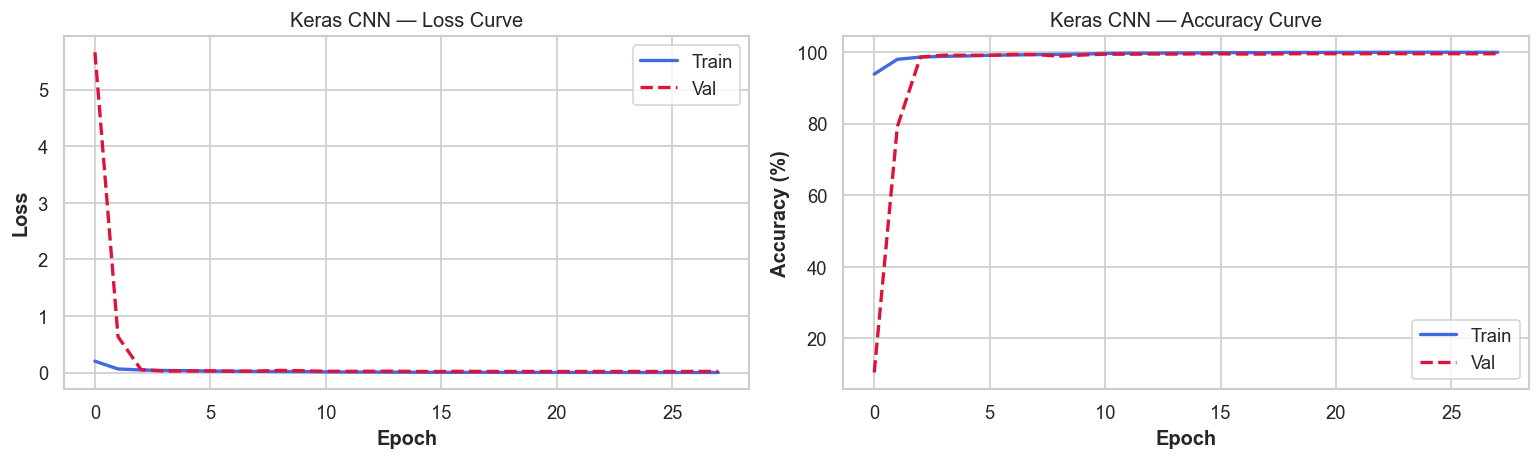

In [31]:
if TF_AVAILABLE and 'history_cnn' in dir():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history_cnn.history['loss'],     label='Train', linewidth=2, color='royalblue')
    axes[0].plot(history_cnn.history['val_loss'], label='Val',   linewidth=2, color='crimson', linestyle='--')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Keras CNN — Loss Curve'); axes[0].legend()

    axes[1].plot(np.array(history_cnn.history['accuracy'])*100,     label='Train', linewidth=2, color='royalblue')
    axes[1].plot(np.array(history_cnn.history['val_accuracy'])*100, label='Val',   linewidth=2, color='crimson', linestyle='--')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Keras CNN — Accuracy Curve'); axes[1].legend()

    plt.tight_layout(); plt.show()

## ─────────────────────────────────────────
## SECTION 10 — Deep Learning: PyTorch CNN
## ─────────────────────────────────────────

In [32]:
if TORCH_AVAILABLE:
    torch.manual_seed(SEED)

    class TorchCNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
                nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
                nn.MaxPool2d(2), nn.Dropout2d(0.25),
                nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
                nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
                nn.MaxPool2d(2), nn.Dropout2d(0.25),
            )
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(64*7*7, 256), nn.ReLU(), nn.Dropout(0.5),
                nn.Linear(256, 10)
            )
        def forward(self, x):
            return self.classifier(self.features(x))

    # ── Data loaders ────────────────────────────────────────────────────────
    X_tr_t = torch.tensor(X_train_norm[:, np.newaxis, :, :], dtype=torch.float32)
    y_tr_t = torch.tensor(y_train, dtype=torch.long)
    X_te_t = torch.tensor(X_test_norm[:, np.newaxis, :, :], dtype=torch.float32)
    y_te_t = torch.tensor(y_test, dtype=torch.long)

    train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=256, shuffle=True)
    test_loader  = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size=512)

    torch_cnn = TorchCNN().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(torch_cnn.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    print(torch_cnn)
    total_params = sum(p.numel() for p in torch_cnn.parameters())
    print(f"\nTotal parameters: {total_params:,}")
else:
    print("PyTorch not available — skipping")

TorchCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout2d(p=0.25, in

In [33]:
if TORCH_AVAILABLE:
    EPOCHS_TORCH = 15
    torch_history = {'train_loss': [], 'train_acc': [], 'val_acc': []}
    t0 = time.time()

    for epoch in range(EPOCHS_TORCH):
        torch_cnn.train()
        ep_loss, correct, total = 0, 0, 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out  = torch_cnn(Xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            ep_loss += loss.item() * Xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
            total   += Xb.size(0)

        # Val accuracy
        torch_cnn.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for Xb, yb in test_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                preds = torch_cnn(Xb).argmax(1)
                val_correct += (preds == yb).sum().item()
                val_total   += Xb.size(0)

        train_loss = ep_loss / total
        train_acc  = correct / total
        val_acc    = val_correct / val_total
        torch_history['train_loss'].append(train_loss)
        torch_history['train_acc'].append(train_acc)
        torch_history['val_acc'].append(val_acc)
        scheduler.step()

        if (epoch+1) % 3 == 0:
            print(f"  Epoch {epoch+1:2d}/{EPOCHS_TORCH}  loss={train_loss:.4f}  "
                  f"train={train_acc*100:.2f}%  val={val_acc*100:.2f}%")

    torch_train_time = time.time() - t0

    # Final predictions
    torch_cnn.eval()
    all_preds = []
    with torch.no_grad():
        for Xb, _ in test_loader:
            all_preds.append(torch_cnn(Xb.to(DEVICE)).argmax(1).cpu().numpy())
    torch_pred = np.concatenate(all_preds)
    torch_acc  = accuracy_score(y_test, torch_pred)
    print(f"\nPyTorch CNN test accuracy: {torch_acc*100:.2f}%  (trained in {torch_train_time:.1f}s)")
    results['PyTorch CNN'] = {'accuracy': torch_acc, 'y_pred': torch_pred,
                               'train_time': torch_train_time, 'inf_time': 0}
else:
    print("Skipping — PyTorch not available")

  Epoch  3/15  loss=0.0634  train=98.16%  val=99.06%
  Epoch  6/15  loss=0.0320  train=99.02%  val=99.48%
  Epoch  9/15  loss=0.0260  train=99.22%  val=99.43%
  Epoch 12/15  loss=0.0180  train=99.45%  val=99.42%
  Epoch 15/15  loss=0.0160  train=99.47%  val=99.45%

PyTorch CNN test accuracy: 99.45%  (trained in 84.5s)


## ─────────────────────────────────────────
## SECTION 11 — Evaluation: Confusion Matrix, ROC, Report
## ─────────────────────────────────────────

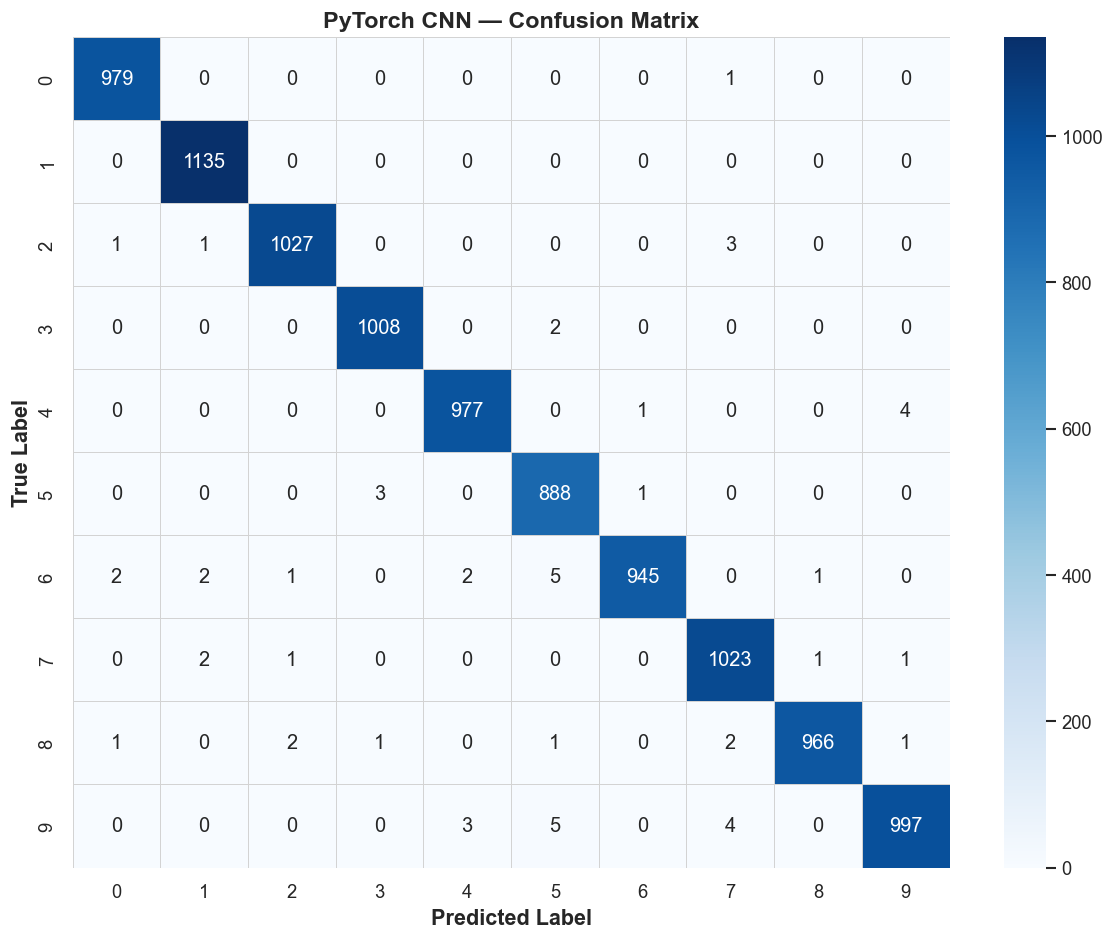

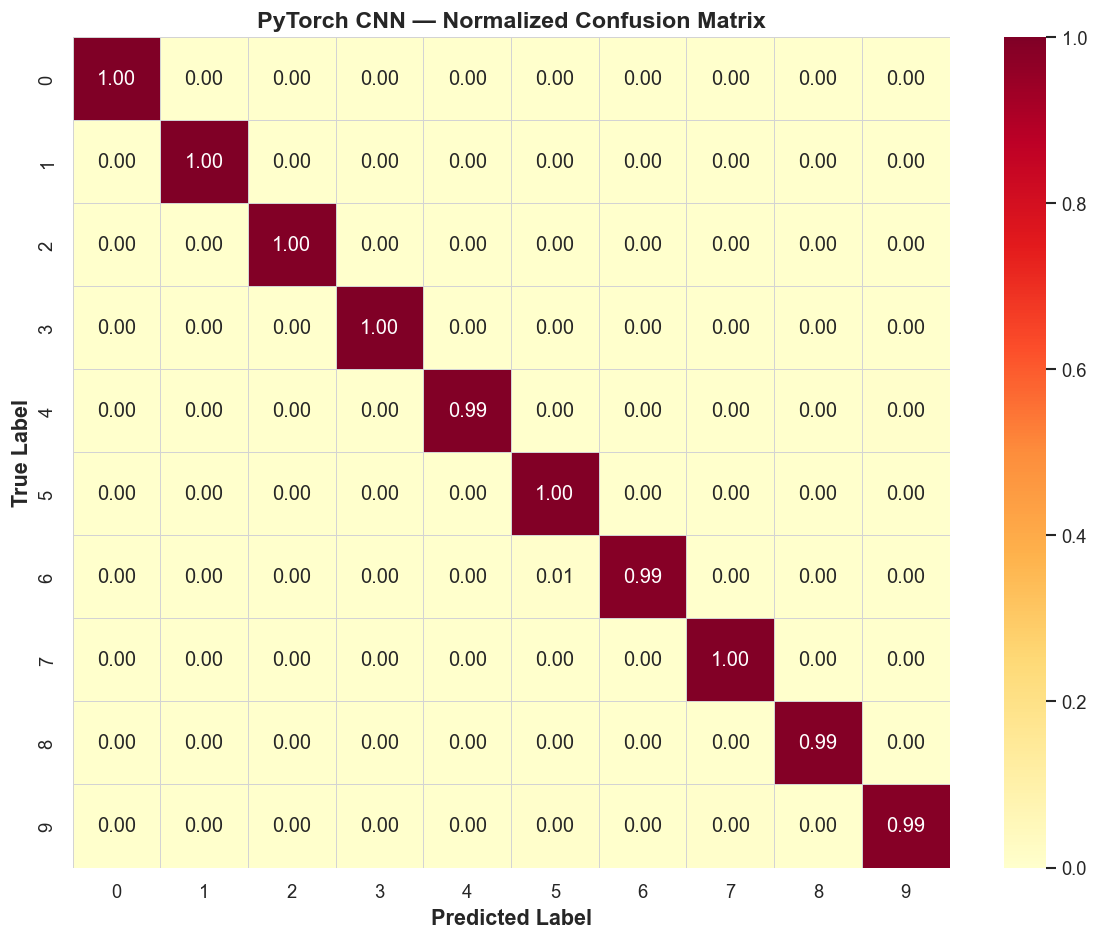

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       1.00      1.00      1.00      1032
           3       1.00      1.00      1.00      1010
           4       0.99      0.99      0.99       982
           5       0.99      1.00      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      1.00      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [34]:
# ── Pick best available predictions ─────────────────────────────────────────
if TORCH_AVAILABLE and 'torch_pred' in dir():
    best_pred = torch_pred
    best_name = 'PyTorch CNN'
elif TF_AVAILABLE and 'cnn_pred' in dir():
    best_pred = cnn_pred
    best_name = 'Keras CNN'
elif TF_AVAILABLE and 'mlp_pred' in dir():
    best_pred = mlp_pred
    best_name = 'Keras MLP'
else:
    best_pred = rf_pred
    best_name = 'Random Forest'

# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, best_pred)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=range(10), yticklabels=range(10),
            linewidths=0.5, linecolor='lightgrey')
ax.set_xlabel('Predicted Label', fontsize=13, fontweight='bold')
ax.set_ylabel('True Label',      fontsize=13, fontweight='bold')
ax.set_title(f'{best_name} — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Normalized confusion matrix ──────────────────────────────────────────────
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            xticklabels=range(10), yticklabels=range(10),
            linewidths=0.5, linecolor='lightgrey')
ax.set_xlabel('Predicted Label', fontsize=13, fontweight='bold')
ax.set_ylabel('True Label',      fontsize=13, fontweight='bold')
ax.set_title(f'{best_name} — Normalized Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(classification_report(y_test, best_pred, target_names=[str(i) for i in range(10)]))

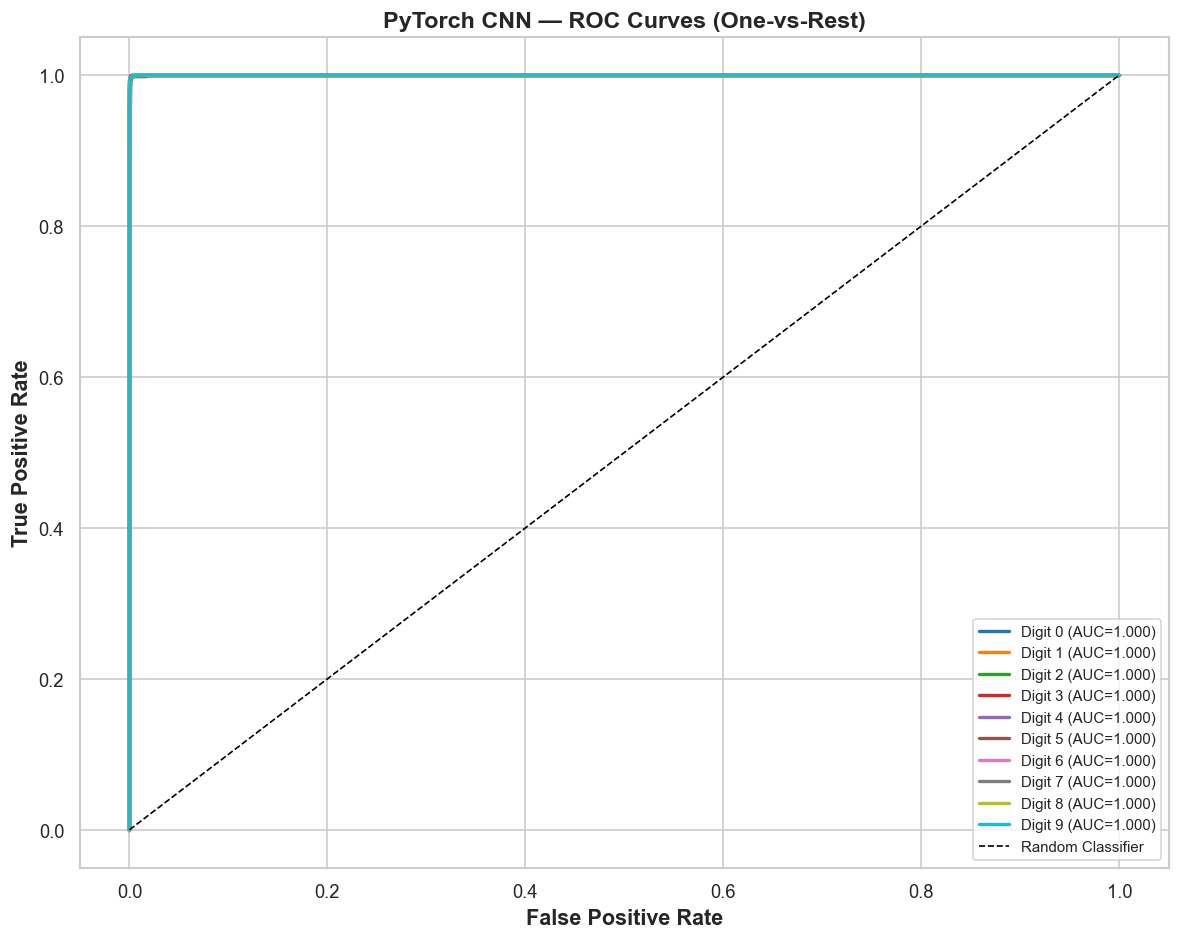

In [35]:
# ── ROC Curves (One-vs-Rest) ─────────────────────────────────────────────────
# Get probability predictions
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)  # (10000, 10)

if TF_AVAILABLE and 'keras_cnn' in dir():
    y_score = keras_cnn.predict(X_test_cnn, verbose=0)
elif TF_AVAILABLE and 'keras_mlp' in dir():
    y_score = keras_mlp.predict(X_test_flat, verbose=0)
elif 'rf_model' in dir():
    y_score = rf_model.predict_proba(X_test_flat)
else:
    y_score = None

if y_score is not None:
    fig, ax = plt.subplots(figsize=(10, 8))
    for i in range(10):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, linewidth=2, label=f'Digit {i} (AUC={roc_auc:.3f})',
                color=colors[i])

    ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random Classifier')
    ax.set_xlabel('False Positive Rate', fontsize=13, fontweight='bold')
    ax.set_ylabel('True Positive Rate',  fontsize=13, fontweight='bold')
    ax.set_title(f'{best_name} — ROC Curves (One-vs-Rest)', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.show()

## ─────────────────────────────────────────
## SECTION 12 — Grad-CAM: What Does the CNN See?
## ─────────────────────────────────────────

Conv layers found: ['conv2d', 'conv2d_1', 'conv2d_2', 'conv2d_3']
Using conv layer for Grad-CAM: conv2d_2


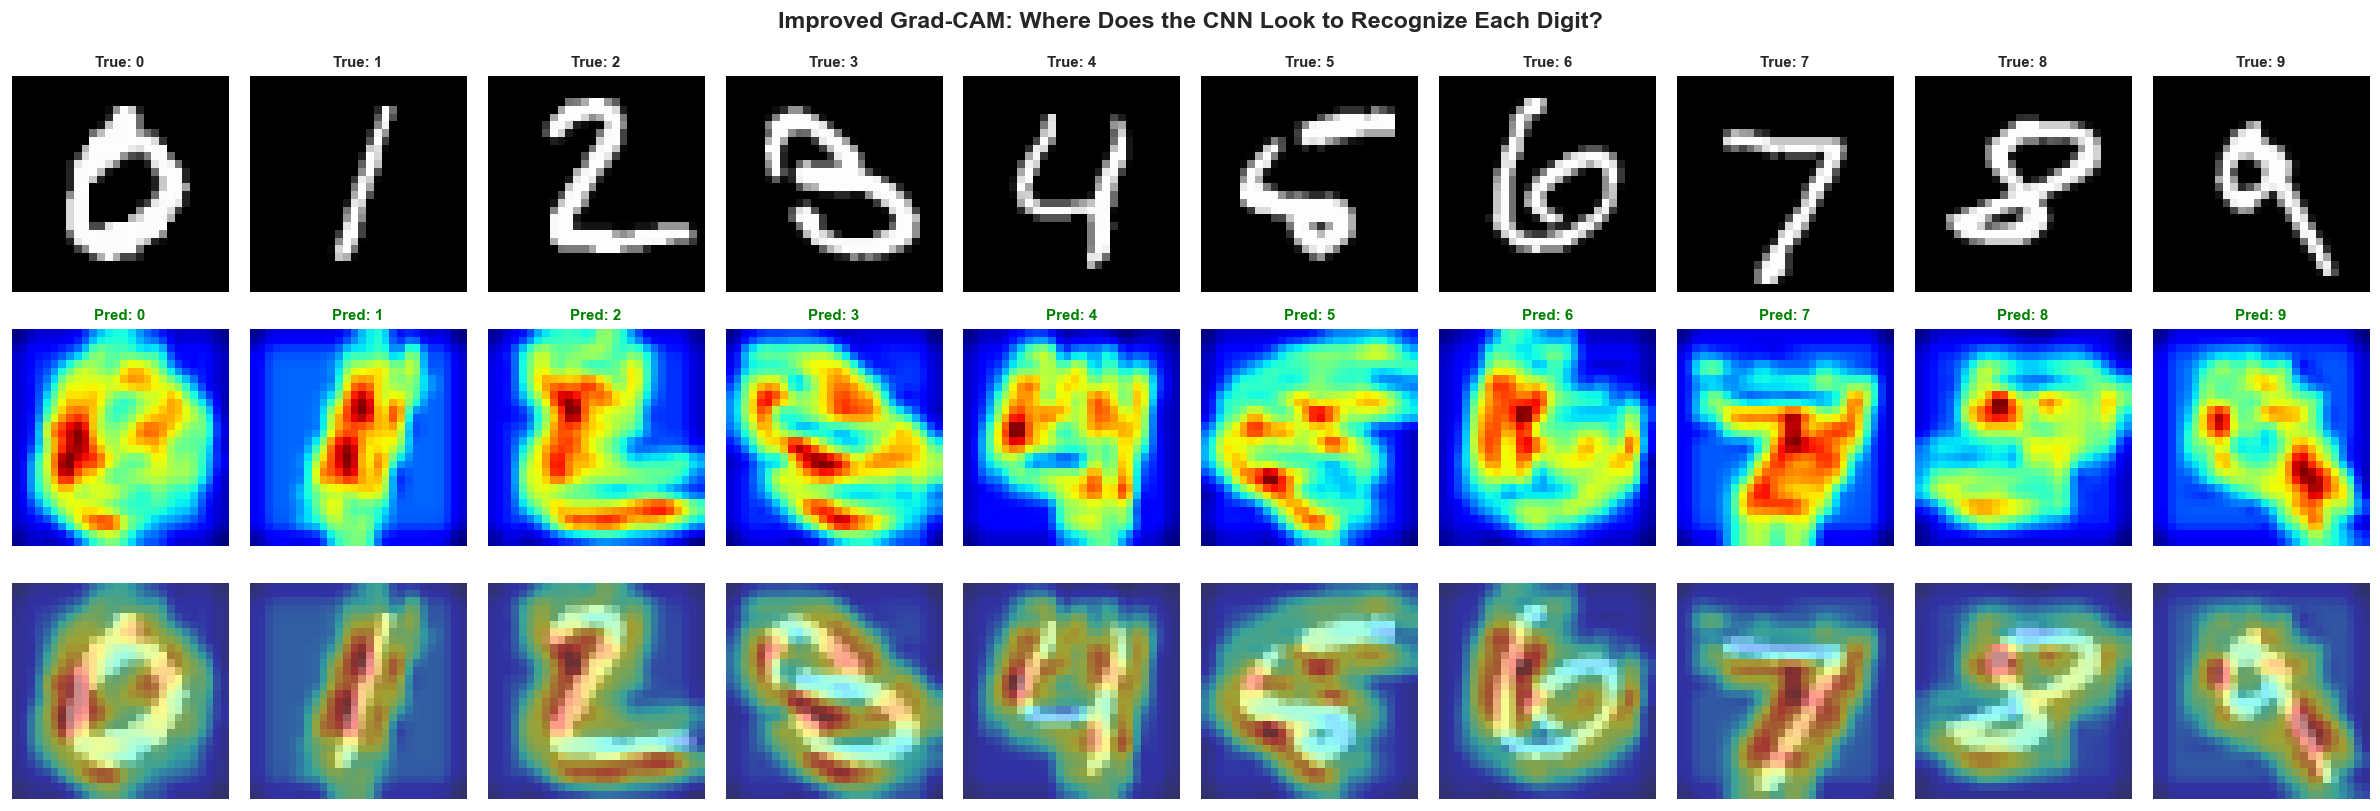

In [36]:
# =========================
# Improved Grad-CAM for MNIST Keras CNN
# =========================

if TF_AVAILABLE and 'keras_cnn' in dir():

    import tensorflow as tf
    import numpy as np
    import matplotlib.pyplot as plt

    def get_gradcam(model, img_array, conv_layer_name):
        """
        Improved Grad-CAM for small MNIST CNN.
        """

        inputs = tf.keras.Input(shape=img_array.shape)

        x = inputs
        conv_output = None

        for layer in model.layers:
            x = layer(x)

            if layer.name == conv_layer_name:
                conv_output = x

        grad_model = tf.keras.Model(
            inputs=inputs,
            outputs=[conv_output, x]
        )

        img_tensor = img_array[np.newaxis, ...]

        with tf.GradientTape() as tape:
            conv_outputs, predictions = grad_model(
                img_tensor,
                training=False
            )

            pred_index = tf.argmax(predictions[0])
            loss = predictions[:, pred_index]

        grads = tape.gradient(loss, conv_outputs)

        guided_grads = (
            tf.cast(conv_outputs > 0, "float32") *
            tf.cast(grads > 0, "float32") *
            grads
        )

        weights = tf.reduce_mean(guided_grads, axis=(1, 2))

        cam = np.zeros(conv_outputs.shape[1:3], dtype=np.float32)

        for i, w in enumerate(weights[0]):
            cam += w * conv_outputs[0, :, :, i]

        cam = np.maximum(cam, 0)

        cam = cam - cam.min()

        if cam.max() != 0:
            cam = cam / cam.max()

        return cam, int(pred_index)

    # -------------------------------------------------
    # Find Conv2D layers
    # -------------------------------------------------
    conv_layers = [
        layer.name
        for layer in keras_cnn.layers
        if isinstance(layer, tf.keras.layers.Conv2D)
    ]

    print("Conv layers found:", conv_layers)

    # Use earlier conv layer if possible
    if len(conv_layers) >= 2:
        selected_conv = conv_layers[-2]
    else:
        selected_conv = conv_layers[-1]

    print(f"Using conv layer for Grad-CAM: {selected_conv}")

    # -------------------------------------------------
    # Plot Grad-CAM for digits 0-9
    # -------------------------------------------------
    fig, axes = plt.subplots(3, 10, figsize=(20, 7))

    for digit in range(10):

        idx = np.where(y_test == digit)[0][0]
        img = X_test_cnn[idx]

        heatmap, pred = get_gradcam(
            keras_cnn,
            img,
            selected_conv
        )

        heatmap_resized = tf.image.resize(
            heatmap[..., np.newaxis],
            [28, 28]
        ).numpy()[:, :, 0]

        axes[0, digit].imshow(img[:, :, 0], cmap='gray')
        axes[0, digit].set_title(
            f"True: {digit}",
            fontsize=9,
            fontweight='bold'
        )
        axes[0, digit].axis('off')

        axes[1, digit].imshow(
            heatmap_resized,
            cmap='jet'
        )
        axes[1, digit].set_title(
            f"Pred: {pred}",
            fontsize=9,
            color='green' if pred == digit else 'red',
            fontweight='bold'
        )
        axes[1, digit].axis('off')

        axes[2, digit].imshow(
            img[:, :, 0],
            cmap='gray',
            alpha=0.65
        )
        axes[2, digit].imshow(
            heatmap_resized,
            cmap='jet',
            alpha=0.45
        )
        axes[2, digit].axis('off')

    axes[0, 0].set_ylabel(
        "Original",
        fontsize=11,
        fontweight='bold'
    )

    axes[1, 0].set_ylabel(
        "Grad-CAM",
        fontsize=11,
        fontweight='bold'
    )

    axes[2, 0].set_ylabel(
        "Overlay",
        fontsize=11,
        fontweight='bold'
    )

    plt.suptitle(
        "Improved Grad-CAM: Where Does the CNN Look to Recognize Each Digit?",
        fontsize=14,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.show()

else:
    print("Grad-CAM requires TensorFlow/Keras CNN — skipping")

## ─────────────────────────────────────────
## SECTION 13 — Error Analysis
## ─────────────────────────────────────────

In [37]:
# ── Find misclassified samples ───────────────────────────────────────────────
wrong_idx = np.where(best_pred != y_test)[0]
print(f"Total errors: {len(wrong_idx)} / {len(y_test)}  ({len(wrong_idx)/len(y_test)*100:.2f}%)")

# ── Most common confusion pairs ──────────────────────────────────────────────
errors_df = pd.DataFrame({
    'true':      y_test[wrong_idx],
    'predicted': best_pred[wrong_idx]
})
confusion_pairs = errors_df.groupby(['true','predicted']).size().reset_index(name='count')
confusion_pairs = confusion_pairs.sort_values('count', ascending=False).head(10)
print("\nTop-10 confusion pairs (True → Predicted):")
print(confusion_pairs.to_string(index=False))

Total errors: 55 / 10000  (0.55%)

Top-10 confusion pairs (True → Predicted):
 true  predicted  count
    9          5      5
    6          5      5
    4          9      4
    9          7      4
    9          4      3
    2          7      3
    5          3      3
    8          2      2
    6          1      2
    6          0      2


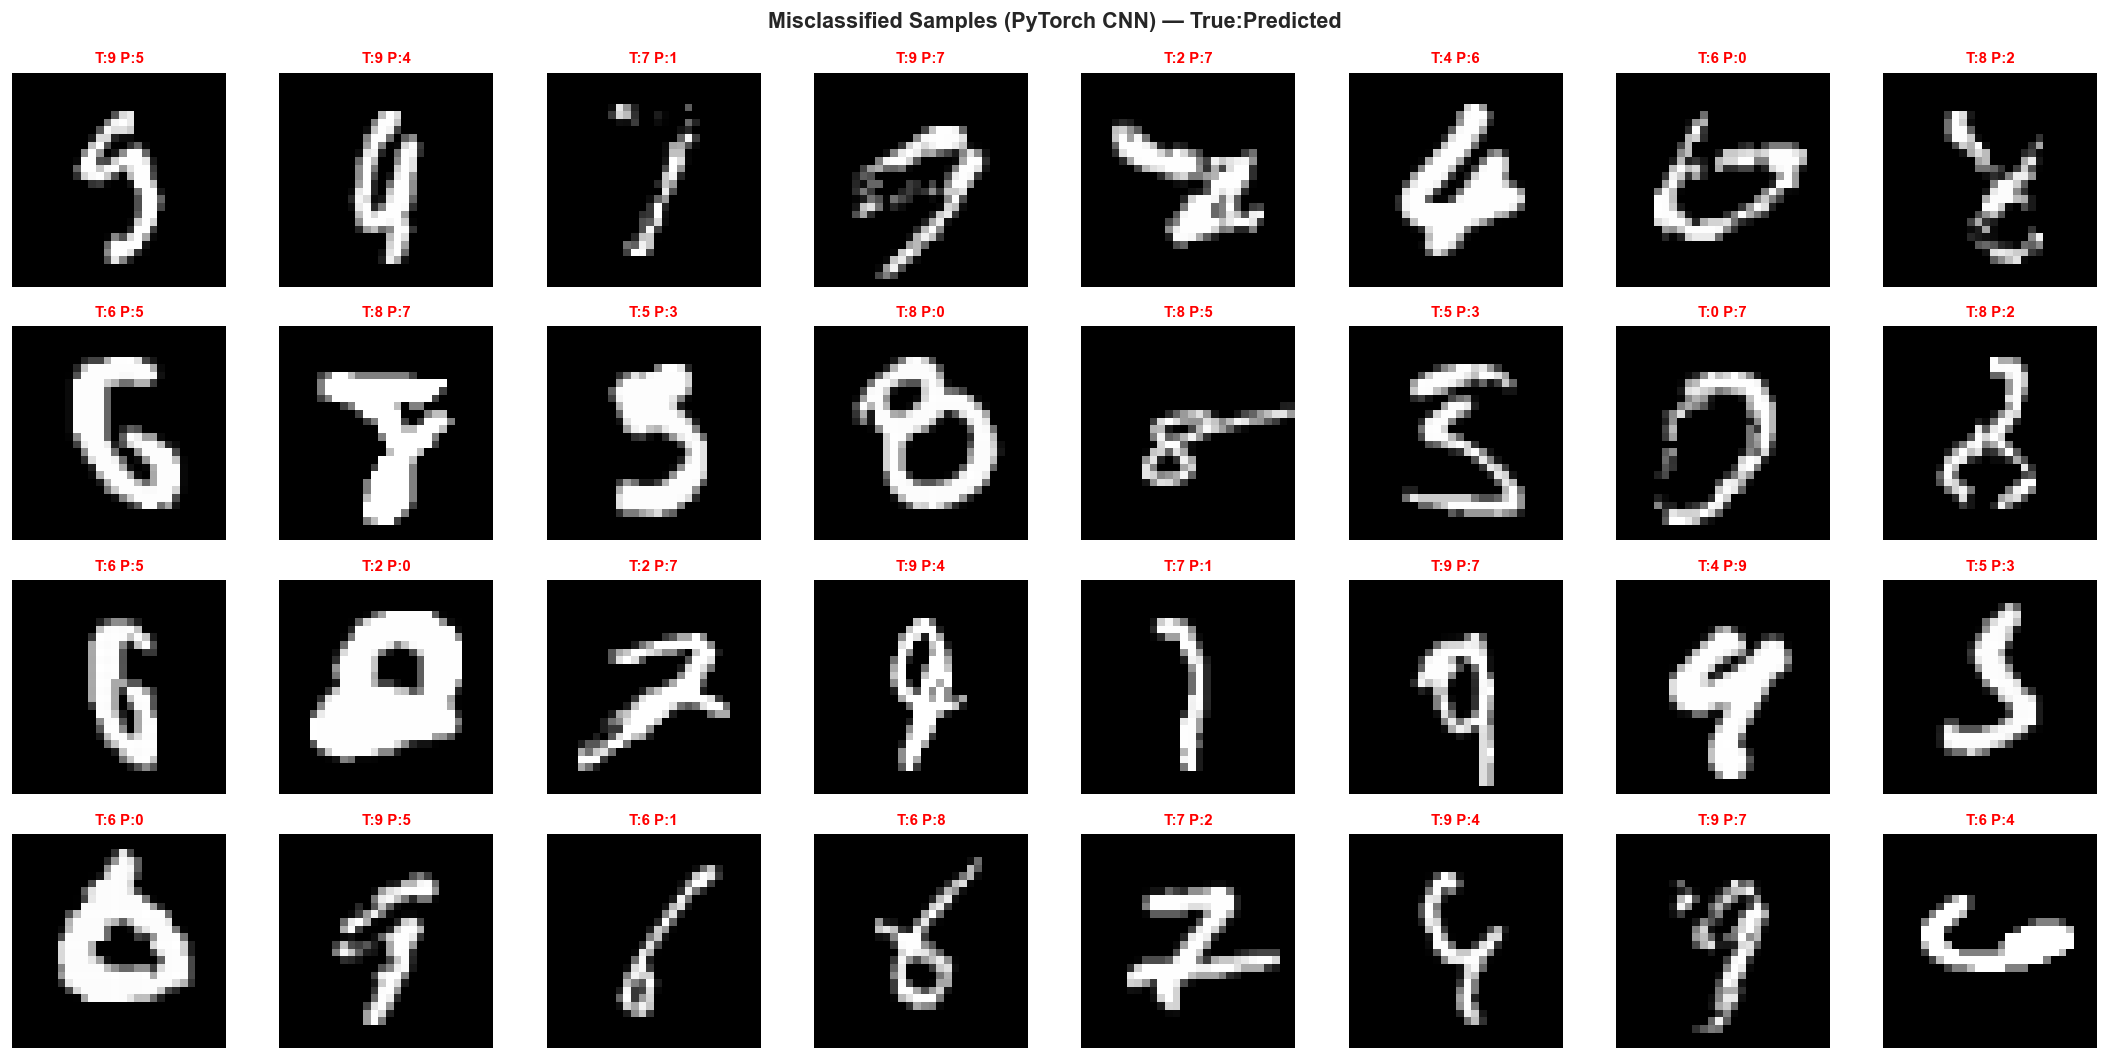

In [38]:
# ── Visualize hard examples ──────────────────────────────────────────────────
fig, axes = plt.subplots(4, 8, figsize=(18, 9))
axes = axes.flatten()
np.random.shuffle(wrong_idx)
for i, ax in enumerate(axes):
    if i >= len(wrong_idx):
        ax.axis('off'); continue
    idx = wrong_idx[i]
    ax.imshow(X_test_raw[idx], cmap='gray')
    ax.set_title(f'T:{y_test[idx]} P:{best_pred[idx]}',
                 fontsize=9, color='red', fontweight='bold')
    ax.axis('off')

plt.suptitle(f'Misclassified Samples ({best_name}) — True:Predicted',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

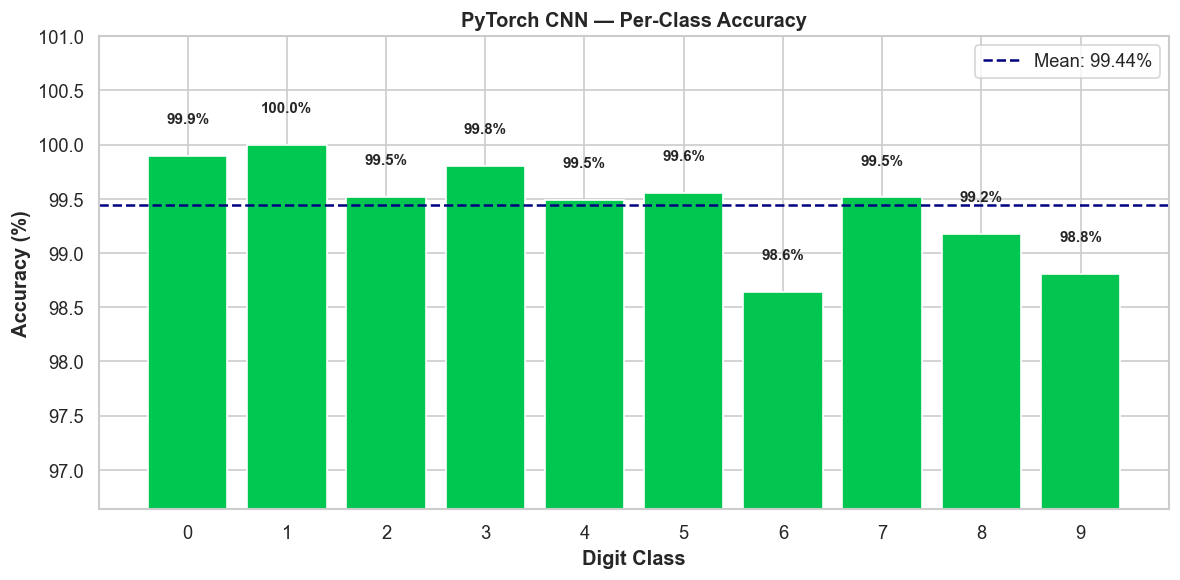

In [39]:
# ── Per-class accuracy ───────────────────────────────────────────────────────
per_class_acc = []
for digit in range(10):
    mask = y_test == digit
    acc  = (best_pred[mask] == digit).mean() * 100
    per_class_acc.append(acc)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(10), per_class_acc,
              color=[f'#{int((1-a/100)*255):02x}{int(a/100*200):02x}50' for a in per_class_acc])
ax.set_xlabel('Digit Class')
ax.set_ylabel('Accuracy (%)')
ax.set_title(f'{best_name} — Per-Class Accuracy', fontweight='bold')
ax.set_xticks(range(10))
ax.set_ylim(min(per_class_acc)-2, 101)
for i, v in enumerate(per_class_acc):
    ax.text(i, v+0.3, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.axhline(np.mean(per_class_acc), color='navy', linestyle='--',
           label=f'Mean: {np.mean(per_class_acc):.2f}%')
ax.legend()
plt.tight_layout()
plt.show()

## ─────────────────────────────────────────
## SECTION 14 — Model Comparison Dashboard
## ─────────────────────────────────────────

In [40]:
# ── Build comparison dataframe ───────────────────────────────────────────────
comparison = pd.DataFrame([
    {'Model': name, 'Accuracy (%)': v['accuracy']*100,
     'Train Time (s)': v.get('train_time', 0)}
    for name, v in results.items()
]).sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)

print("=" * 60)
print("         MODEL COMPARISON LEADERBOARD")
print("=" * 60)
print(comparison.to_string(index=False))
print("=" * 60)

         MODEL COMPARISON LEADERBOARD
              Model  Accuracy (%)  Train Time (s)
          Keras CNN         99.62     1342.000012
        PyTorch CNN         99.45       84.508598
          Keras MLP         98.56       48.332070
    SVM RBF (PCA50)         97.09        1.229557
      Random Forest         95.03        1.116043
            KNN k=5         94.42        0.009854
NumPy MLP (Scratch)         94.42        0.000000
Logistic Regression         90.48      166.772262
      Decision Tree         80.43        2.367732
        Naive Bayes         57.38        0.055976


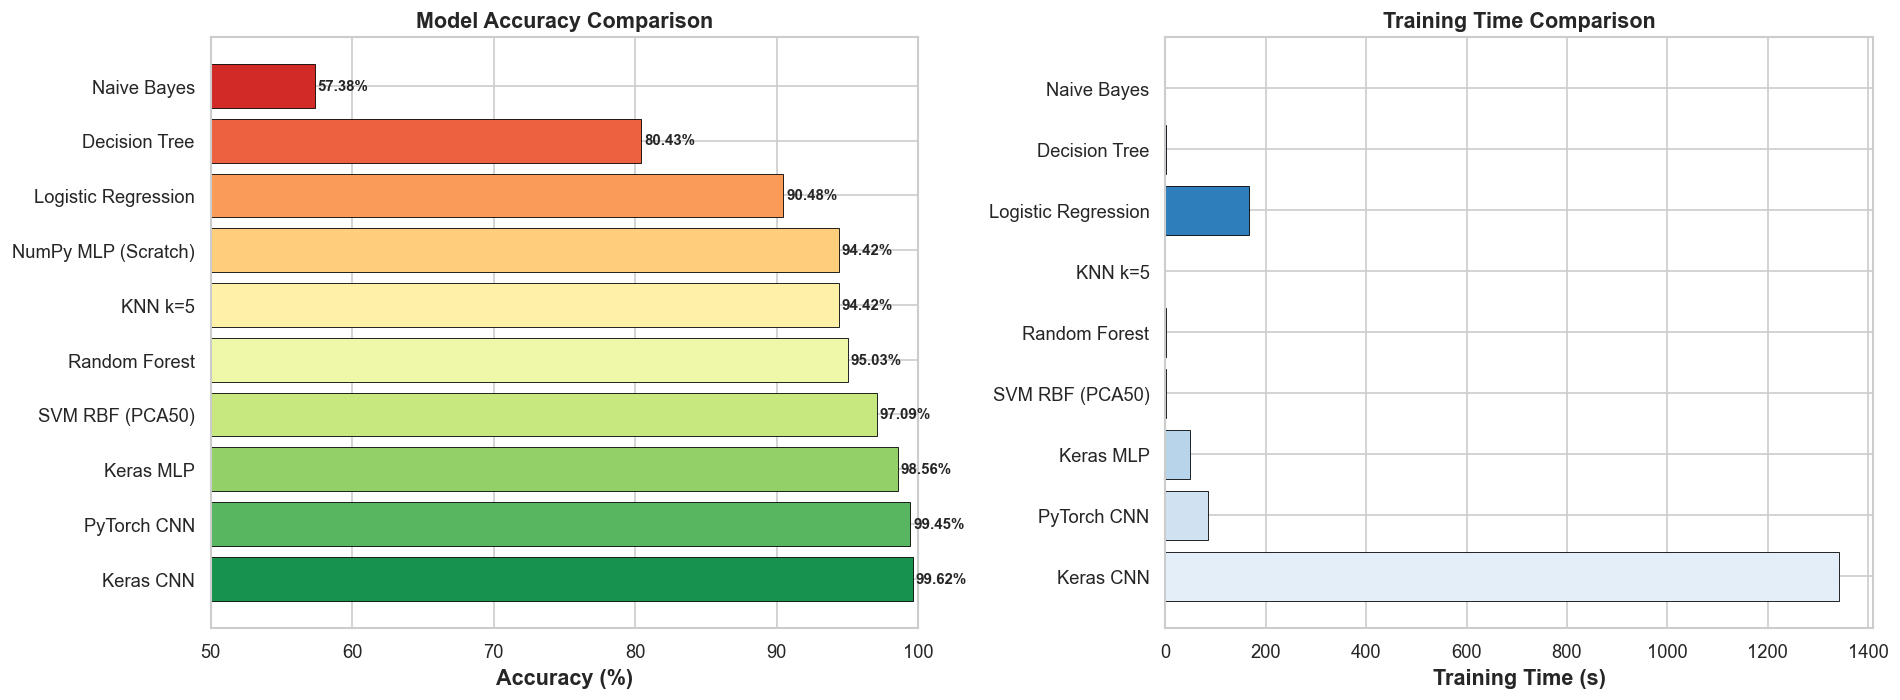

In [41]:
# ── Accuracy bar chart ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pal = sns.color_palette('RdYlGn', len(comparison))
bars = axes[0].barh(comparison['Model'], comparison['Accuracy (%)'],
                    color=pal[::-1], edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Accuracy (%)', fontsize=13, fontweight='bold')
axes[0].set_xlim(50, 100)
axes[0].set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
for bar, acc in zip(bars, comparison['Accuracy (%)']):
    axes[0].text(acc + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{acc:.2f}%', va='center', fontsize=9, fontweight='bold')

# Train time
has_time = comparison[comparison['Train Time (s)'] > 0]
if len(has_time):
    axes[1].barh(has_time['Model'], has_time['Train Time (s)'],
                 color=sns.color_palette('Blues', len(has_time)),
                 edgecolor='black', linewidth=0.5)
    axes[1].set_xlabel('Training Time (s)', fontsize=13, fontweight='bold')
    axes[1].set_title('Training Time Comparison', fontsize=13, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'No timing data', ha='center', va='center', fontsize=14)
    axes[1].axis('off')

plt.tight_layout()
plt.show()

## ─────────────────────────────────────────
## SECTION 15 — Saving, Loading & Inference
## ─────────────────────────────────────────

In [42]:
# ── Save Random Forest ───────────────────────────────────────────────────────
with open('saved_rf_mnist.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print("Random Forest saved → saved_rf_mnist.pkl")

# ── Save Keras CNN ────────────────────────────────────────────────────────────
if TF_AVAILABLE and 'keras_cnn' in dir():
    keras_cnn.save('saved_cnn_mnist.keras')
    print("Keras CNN saved → saved_cnn_mnist.keras")

# ── Save PyTorch CNN ──────────────────────────────────────────────────────────
if TORCH_AVAILABLE and 'torch_cnn' in dir():
    torch.save(torch_cnn.state_dict(), 'saved_torch_cnn_mnist.pth')
    print("PyTorch CNN saved → saved_torch_cnn_mnist.pth")

Random Forest saved → saved_rf_mnist.pkl
Keras CNN saved → saved_cnn_mnist.keras
PyTorch CNN saved → saved_torch_cnn_mnist.pth


✅ Model loaded back from disk


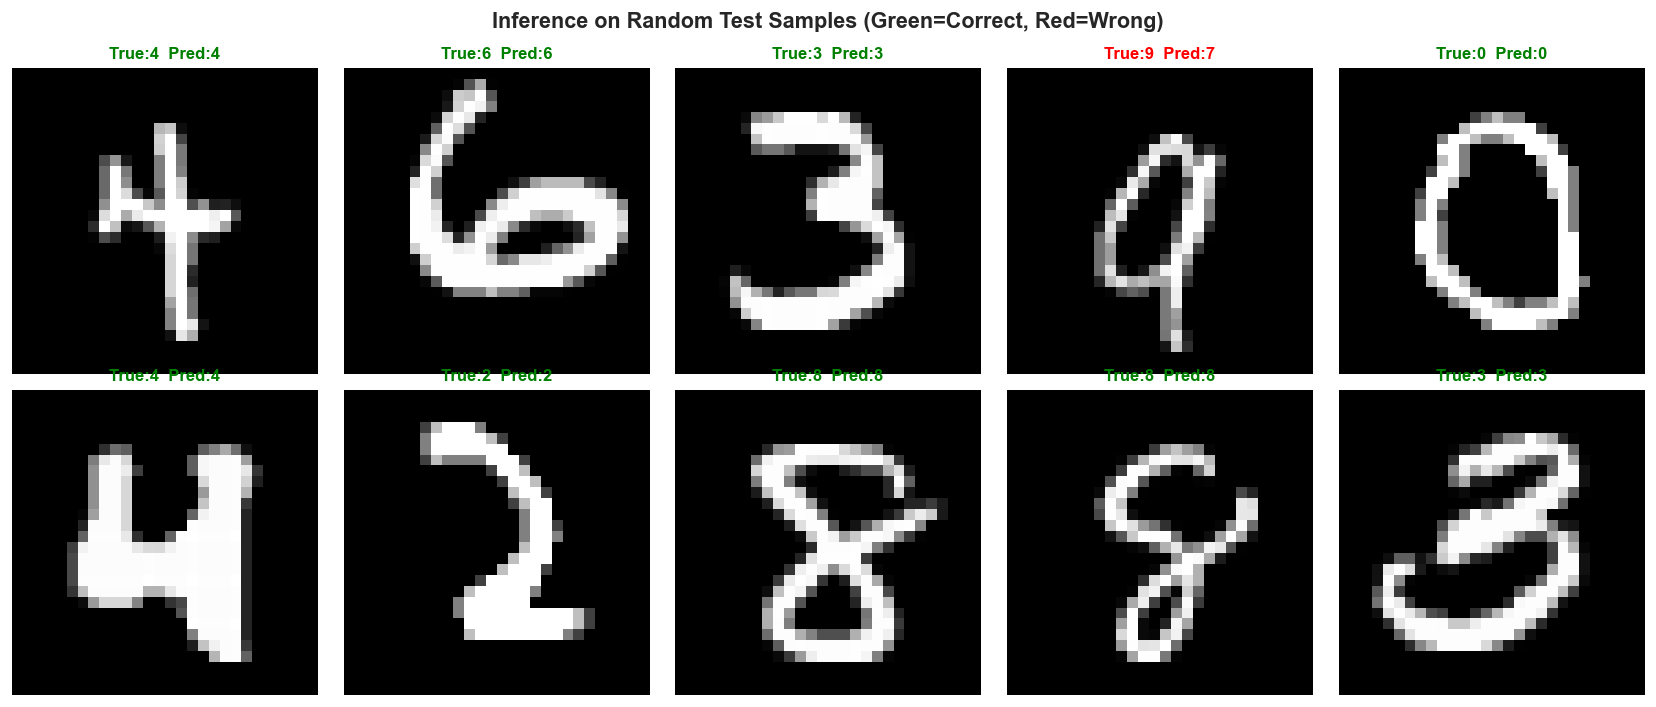

In [43]:
# ── Load & Run Inference ──────────────────────────────────────────────────────
with open('saved_rf_mnist.pkl', 'rb') as f:
    loaded_rf = pickle.load(f)
print("✅ Model loaded back from disk")

# ── Predict on 10 random test samples ────────────────────────────────────────
sample_idx = np.random.choice(len(y_test), 10, replace=False)
samples    = X_test_flat[sample_idx]
preds_rf   = loaded_rf.predict(samples)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, (ax, idx) in enumerate(zip(axes.flatten(), sample_idx)):
    ax.imshow(X_test_raw[idx], cmap='gray')
    color = 'green' if preds_rf[i] == y_test[idx] else 'red'
    ax.set_title(f'True:{y_test[idx]}  Pred:{preds_rf[i]}',
                 color=color, fontweight='bold', fontsize=10)
    ax.axis('off')

plt.suptitle('Inference on Random Test Samples (Green=Correct, Red=Wrong)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

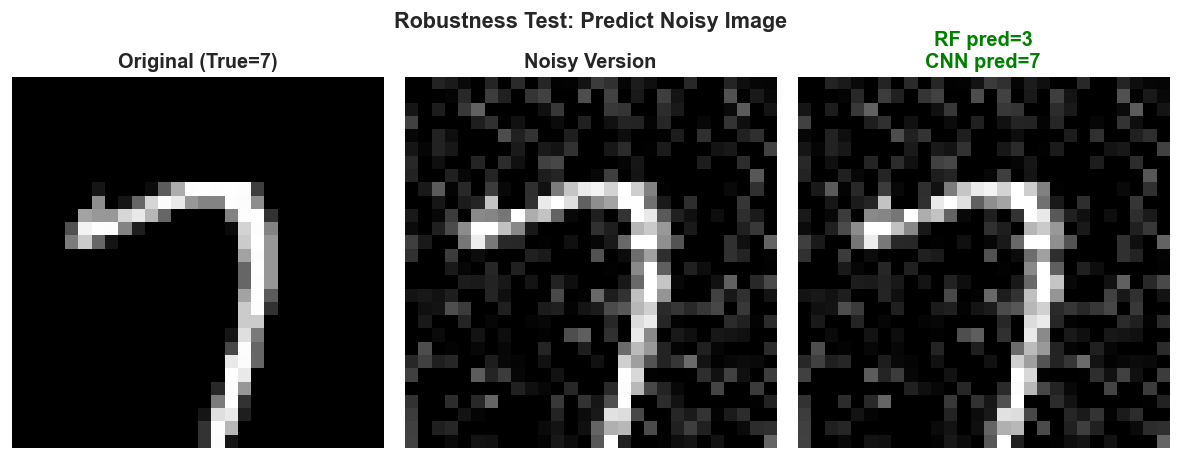

In [44]:
# ── BONUS: Draw Your Own Digit! (Interactive with matplotlib) ─────────────────
# This creates a 28×28 canvas you can "draw" on via mouse
# (Works in Jupyter notebook; requires %matplotlib notebook or ipympl)

# We'll simulate it here with a randomly corrupted sample instead:
digit = 7
idx   = np.where(y_test == digit)[0][2]
base  = X_test_flat[idx].copy()

# Add Gaussian noise to simulate a "handwritten" noisy digit
noisy = np.clip(base + np.random.normal(0, 0.15, base.shape), 0, 1)

pred_rf   = loaded_rf.predict(noisy[np.newaxis])[0]
if TF_AVAILABLE and 'keras_cnn' in dir():
    pred_cnn = np.argmax(keras_cnn.predict(noisy.reshape(1,28,28,1), verbose=0))

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
axes[0].imshow(base.reshape(28,28), cmap='gray')
axes[0].set_title(f'Original (True={digit})', fontweight='bold'); axes[0].axis('off')

axes[1].imshow(noisy.reshape(28,28), cmap='gray')
axes[1].set_title('Noisy Version', fontweight='bold'); axes[1].axis('off')

axes[2].imshow(noisy.reshape(28,28), cmap='gray')
title = f'RF pred={pred_rf}'
if TF_AVAILABLE and 'pred_cnn' in dir():
    title += f'\nCNN pred={pred_cnn}'
axes[2].set_title(title, fontweight='bold', color='green'); axes[2].axis('off')

plt.suptitle('Robustness Test: Predict Noisy Image', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## ─────────────────────────────────────────
## SECTION 16 — BONUS: Data Augmentation
## ─────────────────────────────────────────

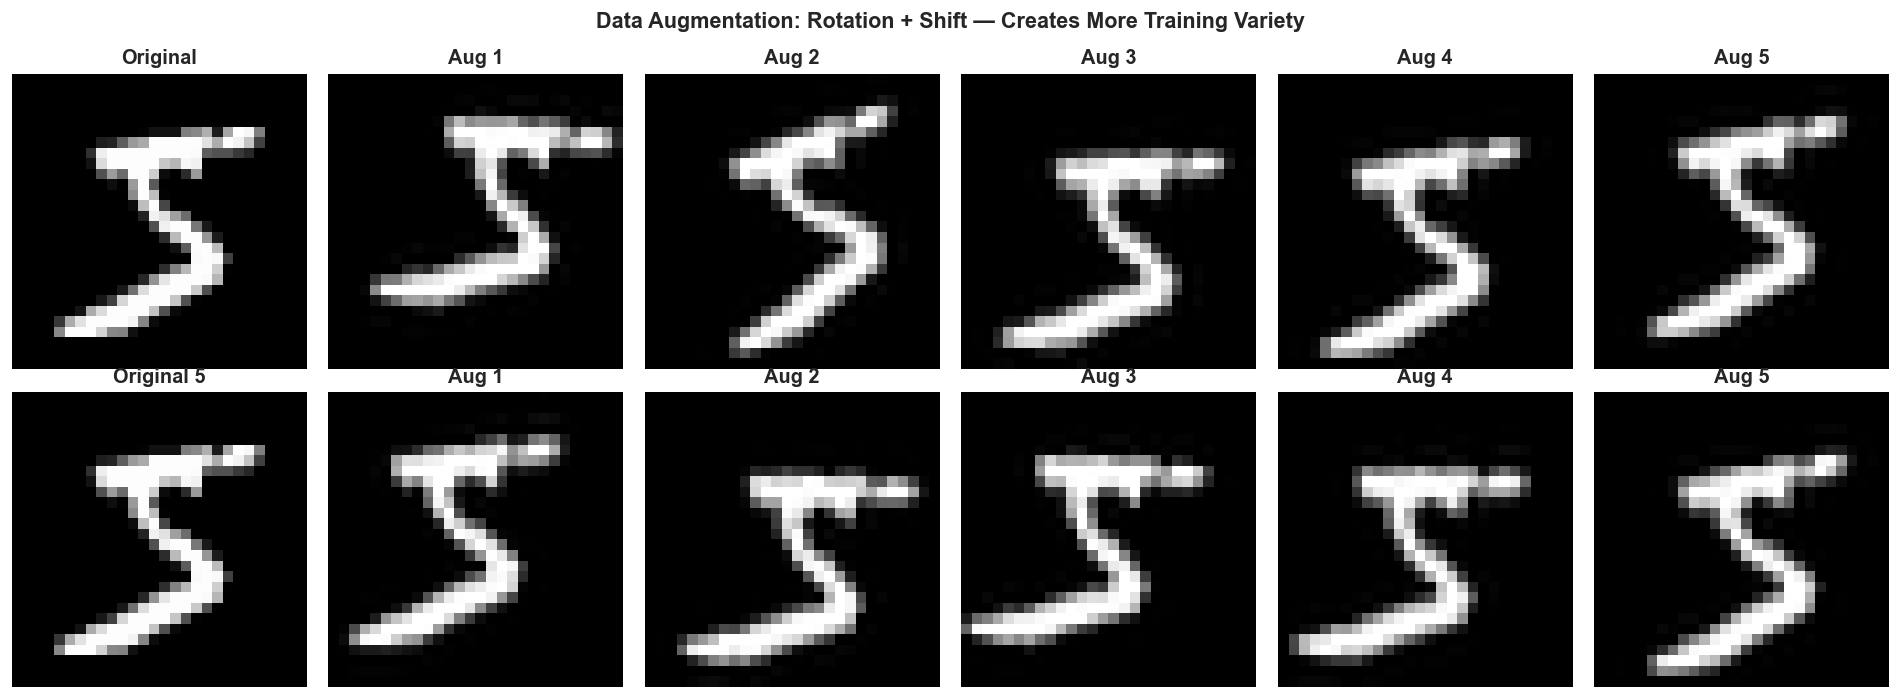

💡 Key insight: Augmentation prevents overfitting by showing the model variations it hasn't seen.


In [45]:
from scipy.ndimage import rotate, shift, zoom

def augment_image(img):
    """Apply random rotation, shift, and zoom to a single 28x28 image."""
    # Random rotation ±15 degrees
    angle = np.random.uniform(-15, 15)
    img   = rotate(img, angle, reshape=False, mode='constant', cval=0)

    # Random shift ±2 pixels
    dx, dy = np.random.uniform(-2, 2, 2)
    img    = shift(img, [dx, dy], mode='constant', cval=0)

    return np.clip(img, 0, 1)

# Visualize augmentations on one digit
base_img = X_train_norm[0]
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
axes[0, 0].imshow(base_img, cmap='gray')
axes[0, 0].set_title('Original', fontweight='bold')
axes[0, 0].axis('off')
axes[1, 0].axis('off')

for col in range(1, 6):
    aug = augment_image(base_img)
    axes[0, col].imshow(aug, cmap='gray')
    axes[0, col].set_title(f'Aug {col}', fontweight='bold')
    axes[0, col].axis('off')

# Different base digit
idx5  = np.where(y_train == 5)[0][0]
base5 = X_train_norm[idx5]
axes[1, 0].imshow(base5, cmap='gray')
axes[1, 0].set_title('Original 5', fontweight='bold')
axes[1, 0].axis('off')

for col in range(1, 6):
    aug = augment_image(base5)
    axes[1, col].imshow(aug, cmap='gray')
    axes[1, col].set_title(f'Aug {col}', fontweight='bold')
    axes[1, col].axis('off')

plt.suptitle('Data Augmentation: Rotation + Shift — Creates More Training Variety',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("💡 Key insight: Augmentation prevents overfitting by showing the model variations it hasn't seen.")

## ─────────────────────────────────────────
## SECTION 17 — BONUS: Hyperparameter Tuning (GridSearch)
## ─────────────────────────────────────────

Running GridSearchCV on KNN (small subset for speed)...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best k          : {'n_neighbors': 5}
Best CV score   : 90.60%


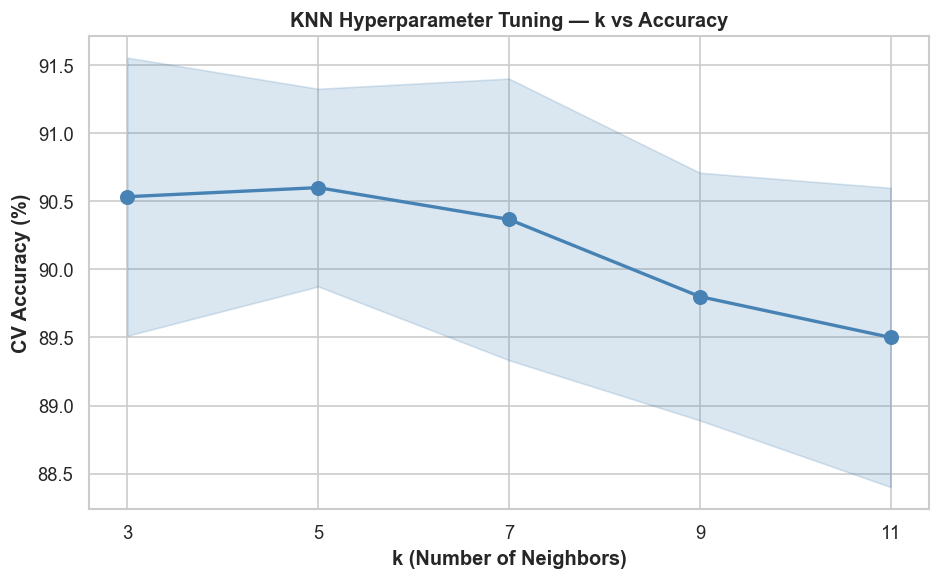

In [46]:
# ── Grid search on KNN ───────────────────────────────────────────────────────
print("Running GridSearchCV on KNN (small subset for speed)...")

param_grid = {'n_neighbors': [3, 5, 7, 9, 11]}
knn_gs = GridSearchCV(
    KNeighborsClassifier(n_jobs=-1),
    param_grid,
    cv=3,
    scoring='accuracy',
    verbose=1
)
knn_gs.fit(Xm_train[:3000], ym_train[:3000])

print(f"\nBest k          : {knn_gs.best_params_}")
print(f"Best CV score   : {knn_gs.best_score_*100:.2f}%")

# ── Plot CV results ──────────────────────────────────────────────────────────
cv_results = pd.DataFrame(knn_gs.cv_results_)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(param_grid['n_neighbors'], cv_results['mean_test_score']*100, 'o-',
        linewidth=2, color='steelblue', markersize=8)
ax.fill_between(
    param_grid['n_neighbors'],
    (cv_results['mean_test_score'] - cv_results['std_test_score'])*100,
    (cv_results['mean_test_score'] + cv_results['std_test_score'])*100,
    alpha=0.2, color='steelblue'
)
ax.set_xlabel('k (Number of Neighbors)', fontweight='bold')
ax.set_ylabel('CV Accuracy (%)', fontweight='bold')
ax.set_title('KNN Hyperparameter Tuning — k vs Accuracy', fontweight='bold')
ax.set_xticks(param_grid['n_neighbors'])
plt.tight_layout()
plt.show()

## ─────────────────────────────────────────
## SECTION 18 — BONUS: Cross-Validation
## ─────────────────────────────────────────

5-Fold Cross-Validation on subset (3000 samples)...

  Logistic Regression        Mean=88.77%  Std=1.68%
  Decision Tree              Mean=73.40%  Std=2.85%
  Random Forest              Mean=91.30%  Std=1.79%
  KNN k=5                    Mean=90.97%  Std=1.79%


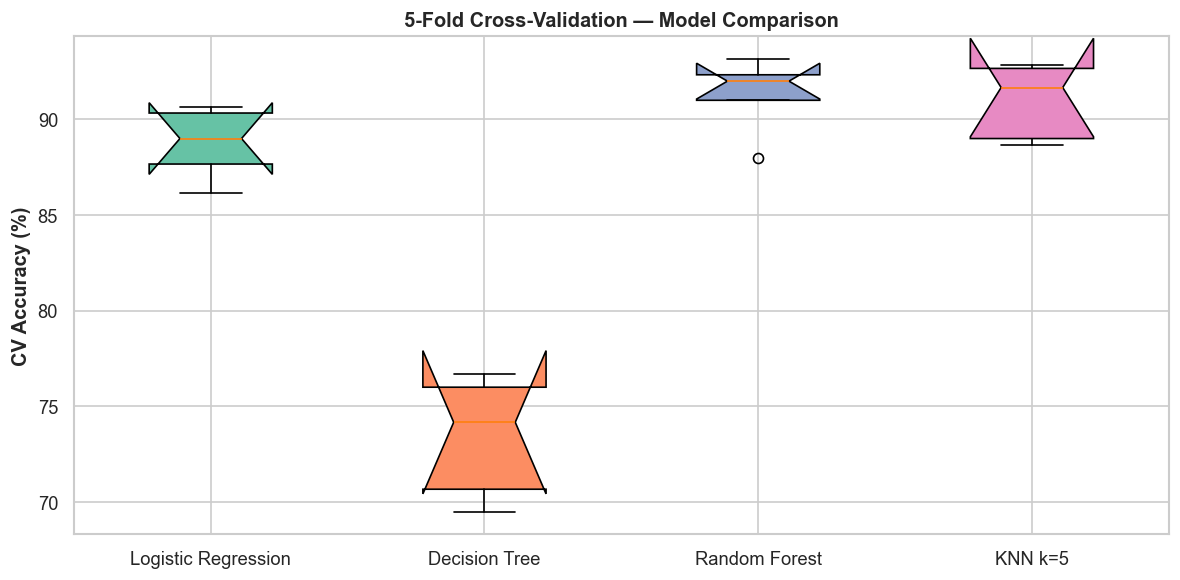

In [47]:
print("5-Fold Cross-Validation on subset (3000 samples)...\n")

cv_models = {
    'Logistic Regression': LogisticRegression(max_iter=200, solver='saga', random_state=SEED),
    'Decision Tree':       DecisionTreeClassifier(max_depth=15, random_state=SEED),
    'Random Forest':       RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=SEED),
    'KNN k=5':             KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
}

cv_results_dict = {}
for name, model in cv_models.items():
    scores = cross_val_score(model, Xm_train[:3000], ym_train[:3000], cv=5, scoring='accuracy', n_jobs=-1)
    cv_results_dict[name] = scores
    print(f"  {name:<25}  Mean={scores.mean()*100:.2f}%  Std={scores.std()*100:.2f}%")

# ── Boxplot comparison ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
data = [v*100 for v in cv_results_dict.values()]
bp = ax.boxplot(data, labels=cv_results_dict.keys(), patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], sns.color_palette('Set2', len(cv_models))):
    patch.set_facecolor(color)
ax.set_ylabel('CV Accuracy (%)', fontweight='bold')
ax.set_title('5-Fold Cross-Validation — Model Comparison', fontweight='bold')
plt.tight_layout()
plt.show()

## ─────────────────────────────────────────
## FINAL SUMMARY
## ─────────────────────────────────────────

In [48]:
print("="*65)
print("         MNIST ZERO-TO-HERO — FINAL LEADERBOARD")
print("="*65)
print(f"{'Rank':<6}{'Model':<35}{'Accuracy':>10}")
print("-"*65)
for rank, row in comparison.iterrows():
    marker = '🏆' if rank == 0 else '  '
    print(f"  {rank+1:<5}{row['Model']:<35}{row['Accuracy (%)']:>9.2f}%  {marker}")
print("="*65)

print("""
Key Takeaways:
──────────────
✔  Raw pixels alone are surprisingly informative (KNN works well)
✔  PCA reduces dimensionality without losing much accuracy
✔  CNNs dominate because they exploit spatial structure
✔  Data augmentation → better generalization
✔  Always evaluate with confusion matrix + per-class metrics
✔  Grad-CAM shows WHY a network makes each decision
✔  Always save your best model!

Next Steps for Students:
────────────────────────
→  Try on FashionMNIST (drop-in replacement, harder)
→  Implement ResNet / VGG and compare
→  Add advanced augmentation (elastic distortion)
→  Explore knowledge distillation (compress CNN → MLP)
→  Deploy as a Flask/Streamlit web app
""")

         MNIST ZERO-TO-HERO — FINAL LEADERBOARD
Rank  Model                                Accuracy
-----------------------------------------------------------------
  1    Keras CNN                              99.62%  🏆
  2    PyTorch CNN                            99.45%    
  3    Keras MLP                              98.56%    
  4    SVM RBF (PCA50)                        97.09%    
  5    Random Forest                          95.03%    
  6    KNN k=5                                94.42%    
  7    NumPy MLP (Scratch)                    94.42%    
  8    Logistic Regression                    90.48%    
  9    Decision Tree                          80.43%    
  10   Naive Bayes                            57.38%    

Key Takeaways:
──────────────
✔  Raw pixels alone are surprisingly informative (KNN works well)
✔  PCA reduces dimensionality without losing much accuracy
✔  CNNs dominate because they exploit spatial structure
✔  Data augmentation → better generalization
✔  Alway